In [ ]:

import os
import json
import httpx
from stream_unzip import stream_unzip
from tqdm.auto import tqdm

SKIP THE BELOW CELL I UPLOADED THE MODIFIED DATASET

In [ ]:
output_file = "WorldTrace_Sample_20k.json"

# Settings
limit = 20000
output_file = "WorldTrace_Sample_20k.json"
url = "https://huggingface.co/datasets/OpenTrace/WorldTrace/resolve/main/Meta.zip"

# Get your token if the repo is private/gated
headers = {}
if "HF_TOKEN" in os.environ:
    headers["Authorization"] = f"Bearer {os.environ['HF_TOKEN']}"

print(f"🌊 Streaming first {limit} files from Meta.zip...")

samples = []

# This function feeds the downloader chunks of data
def zipped_chunks():
    with httpx.stream("GET", url, headers=headers, follow_redirects=True) as r:
        yield from r.iter_bytes(chunk_size=65536)

try:
    # stream_unzip reads the zip from the start (no central directory needed)
    for i, (fname, file_size, chunks) in tqdm(enumerate(stream_unzip(zipped_chunks())), total=limit, unit="files"):
        
        # Decode the file name
        name = fname.decode('utf-8')
        
        # We only want JSON files
        if name.endswith('.json'):
            # Read the file content into memory
            content = b"".join(chunks)
            
            try:
                data = json.loads(content)
                samples.append(data)
            except json.JSONDecodeError:
                pass # Skip broken files

            # STOP once we hit the limit
            if len(samples) >= limit:
                print(f"\n🛑 Reached {limit} samples. Stopping download.")
                break
        else:
            # Important: You must consume the chunks even if you skip the file
            for _ in chunks:
                pass

    # Save to disk
    print(f"💾 Saving to {output_file}...")
    with open(output_file, 'w') as f:
        json.dump(samples, f)

    print("✓ Done!")

    with open("WorldTrace_20k.jsonl", "w") as f:
        for sample in samples:
            # Write one line at a time
            f.write(json.dumps(sample) + "\n")

    print("✓ Done! Converted to jsonl")

except Exception as e:
    print(f"\nError: {e}")
    if len(samples) > 0:
        print(f"Saving the {len(samples)} samples we managed to get...")
        with open(output_file, 'w') as f:
            json.dump(samples, f)



🌊 Streaming first 20000 files from Meta.zip...


  0%|          | 0/20000 [00:00<?, ?files/s]


🛑 Reached 20000 samples. Stopping download.
💾 Saving to WorldTrace_Sample_20k.json...
✓ Done!
✓ Done!


In [6]:
import json
import os

# 1. We must define the filename again
output_file = "WorldTrace_Sample_20k.json"
# 2. Check if the file actually exists before trying to read it
if not os.path.exists(output_file):
    print(f"❌ Error: Could not find '{output_file}'.")
    print("Please run the download script from the previous step first.")

else:
    try:
        # 3. Load and display
        with open(output_file, 'r') as f:
            data = json.load(f)

        print(f"✅ File loaded successfully!")
        print(f"Total paths in file: {len(data)}\n")
        
        print("First 5 paths:")
        for i, path in enumerate(data[:5]):
            print(f"\n{i+1}. Filename: {path.get('Filename', 'N/A')}")
            print(f"   Distance: {path.get('Distance', 'N/A')}m")
            print(f"   Duration: {path.get('Time', 'N/A')}s")
            print(f"   Geometry points: {len(path.get('geometry', []))}")

    except json.JSONDecodeError:
        print("❌ Error: The file exists but is corrupted.")
        print("This usually happens if the download was stopped while writing the file.")

✅ File loaded successfully!
Total paths in file: 20000

First 5 paths:

1. Filename: 2022_07_20T01_18_27.591242Z.gpx
   Distance: 455.6308553917523m
   Duration: 57.0s
   Geometry points: 74

2. Filename: 2023_02_08T03_37_45.045645Z.gpx
   Distance: 15028.128753511506m
   Duration: 599.0s
   Geometry points: 912

3. Filename: 2023_02_05T00_44_30.794945Z.gpx
   Distance: 564.1129088028989m
   Duration: 77.0s
   Geometry points: 83

4. Filename: 2022_12_05T04_56_31.317111Z.gpx
   Distance: 12467.653081915985m
   Duration: 434.0s
   Geometry points: 562

5. Filename: 2023_03_05T19_33_12.870908Z.gpx
   Distance: 11085.979230037105m
   Duration: 602.0s
   Geometry points: 707


In [7]:
# Instead of json.dump(samples, f)
with open("WorldTrace_20k.jsonl", "w") as f:
    for sample in samples:
        # Write one line at a time
        f.write(json.dumps(sample) + "\n")

In [15]:
import json

filename = "WorldTrace_20k.jsonl"

def get_data_by_index(indx: int):
    with open(filename, 'r') as f:
        for i, line in enumerate(f):
            if i == indx:
                return json.loads(line)
    return None

In [14]:
print(get_data_by_index(1).keys())


dict_keys(['Filename', 'Uploaded', 'Points', 'Start coordinate', 'Owner', 'Description', 'Tags', 'Visibility', 'Distance', 'Time', 'geometry'])


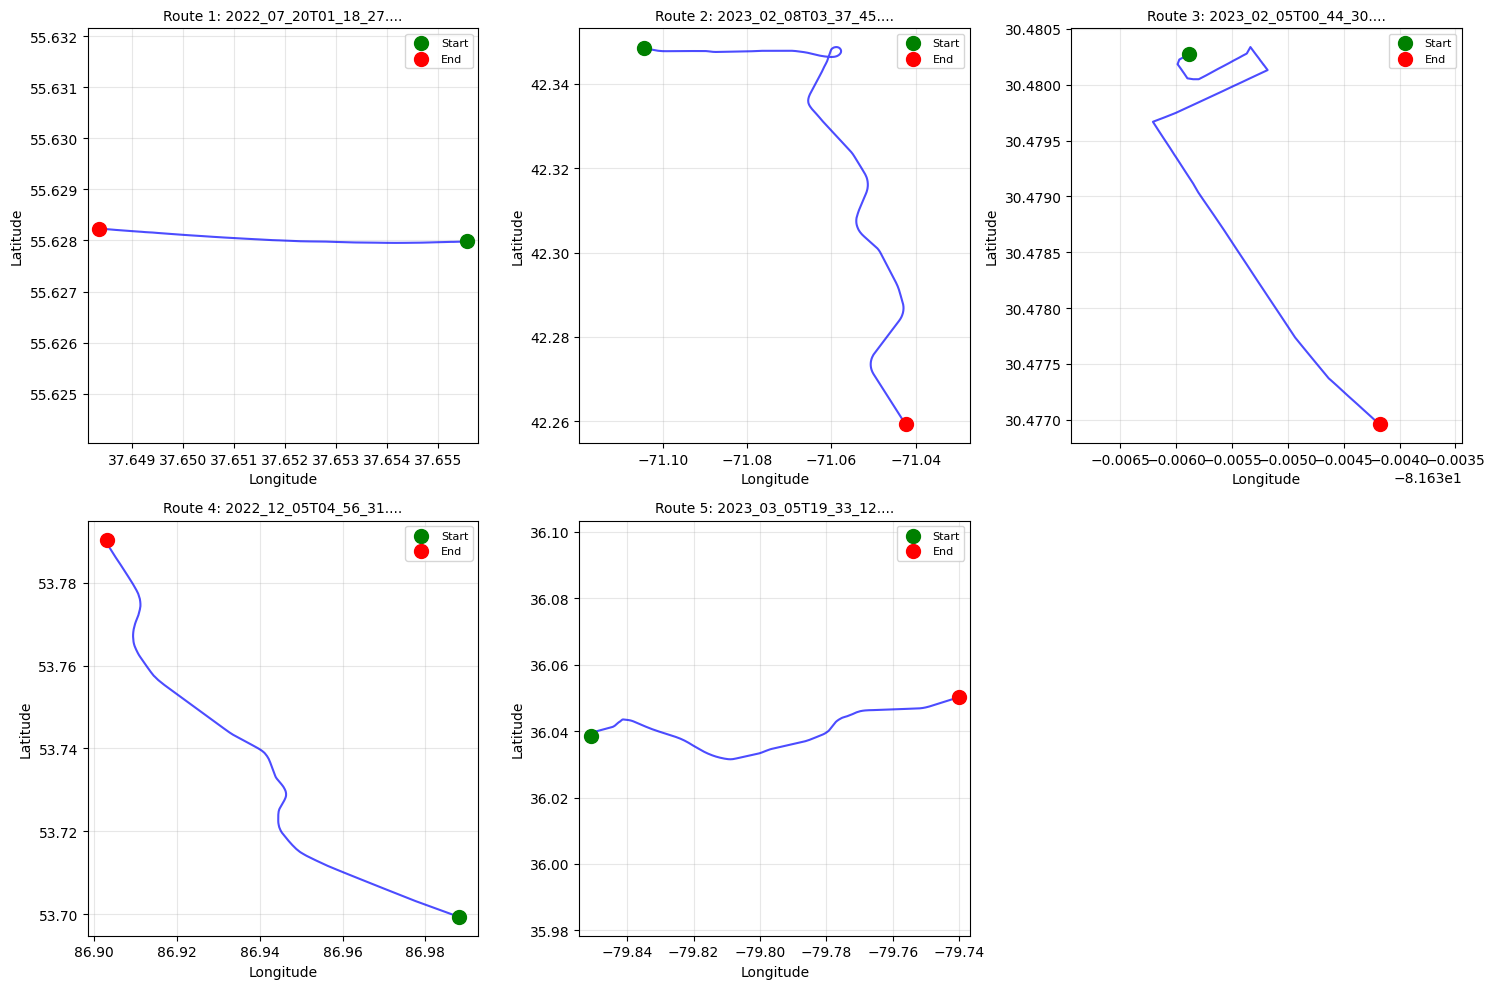


📍 Route Details:

1. 2022_07_20T01_18_27.591242Z.gpx
   Distance: 455.6308553917523m
   Duration: 57.0s
   Points: 74

2. 2023_02_08T03_37_45.045645Z.gpx
   Distance: 15028.128753511506m
   Duration: 599.0s
   Points: 912

3. 2023_02_05T00_44_30.794945Z.gpx
   Distance: 564.1129088028989m
   Duration: 77.0s
   Points: 83

4. 2022_12_05T04_56_31.317111Z.gpx
   Distance: 12467.653081915985m
   Duration: 434.0s
   Points: 562

5. 2023_03_05T19_33_12.870908Z.gpx
   Distance: 11085.979230037105m
   Duration: 602.0s
   Points: 707



In [16]:
import json
import matplotlib.pyplot as plt

# Get first 5 routes using get_data_by_index
routes = []
for i in range(5):
    route = get_data_by_index(i)
    if route:
        routes.append(route)

# Plot all 5 routes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, route in enumerate(routes):
    ax = axes[idx]
    
    geometry = route.get('geometry', [])
    if geometry:
        lons = [point[0] for point in geometry]
        lats = [point[1] for point in geometry]
        
        ax.plot(lons, lats, 'b-', linewidth=1.5, alpha=0.7)
        ax.scatter(lons[0], lats[0], color='green', s=100, label='Start', zorder=5)
        ax.scatter(lons[-1], lats[-1], color='red', s=100, label='End', zorder=5)
        
        ax.set_title(f"Route {idx+1}: {route.get('Filename', 'Unknown')[:20]}...", fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    else:
        ax.text(0.5, 0.5, 'No geometry data', ha='center', va='center')
        ax.set_title(f"Route {idx+1}: No data")

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Print route info
print("\n📍 Route Details:\n")
for i, route in enumerate(routes):
    print(f"{i+1}. {route.get('Filename', 'Unknown')}")
    print(f"   Distance: {route.get('Distance', 'N/A')}m")
    print(f"   Duration: {route.get('Time', 'N/A')}s")
    print(f"   Points: {len(route.get('geometry', []))}\n")

In [20]:
##display the route on the actual map.

import folium

# Get first route
route = get_data_by_index(10)
geometry = route.get('geometry', [])

if geometry:
    # Calculate center of route
    lats = [point[1] for point in geometry]
    lons = [point[0] for point in geometry]
    center_lat = sum(lats) / len(lats)
    center_lon = sum(lons) / len(lons)
    
    # Create map centered on route
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
    
    # Draw the route as a line
    folium.PolyLine(
        locations=[[lat, lon] for lon, lat in geometry],
        color='blue',
        weight=3,
        opacity=0.8,
        tooltip=route.get('Filename', 'Route')
    ).add_to(m)
    
    # Add start marker (green)
    folium.Marker(
        location=[geometry[0][1], geometry[0][0]],
        popup='Start',
        icon=folium.Icon(color='green', icon='play')
    ).add_to(m)
    
    # Add end marker (red)
    folium.Marker(
        location=[geometry[-1][1], geometry[-1][0]],
        popup='End',
        icon=folium.Icon(color='red', icon='stop')
    ).add_to(m)
    
    # Display map
    display(m)

In [22]:
#Normalize the data
import numpy as np
from scipy.interpolate import interp1d

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in meters between two points"""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def normalize_route_relative(geometry):
    """Method 1: Convert to relative distances from start (in meters)"""
    if not geometry or len(geometry) < 2:
        return None
    
    start_lon, start_lat = geometry[0]
    normalized = []
    
    for lon, lat in geometry:
        # Calculate x (east-west) and y (north-south) distances from start
        x = haversine_distance(start_lat, start_lon, start_lat, lon)
        y = haversine_distance(start_lat, start_lon, lat, start_lon)
        
        # Preserve direction (negative if west/south of start)
        if lon < start_lon:
            x = -x
        if lat < start_lat:
            y = -y
            
        normalized.append([x, y])
    
    return np.array(normalized)

def normalize_route_fixed_length(geometry, n_points=100):
    """Method 2: Resample route to fixed number of points"""
    if not geometry or len(geometry) < 2:
        return None
    
    geometry = np.array(geometry)
    
    # Calculate cumulative distance along route
    distances = [0]
    for i in range(1, len(geometry)):
        dist = haversine_distance(
            geometry[i-1][1], geometry[i-1][0],
            geometry[i][1], geometry[i][0]
        )
        distances.append(distances[-1] + dist)
    
    distances = np.array(distances)
    
    # Interpolate to get n_points evenly spaced along route
    if len(geometry) < 4:  # Need at least 4 points for cubic
        kind = 'linear'
    else:
        kind = 'cubic'
    
    interp_lon = interp1d(distances, geometry[:, 0], kind=kind)
    interp_lat = interp1d(distances, geometry[:, 1], kind=kind)
    
    # Sample at evenly spaced distances
    new_distances = np.linspace(0, distances[-1], n_points)
    new_lons = interp_lon(new_distances)
    new_lats = interp_lat(new_distances)
    
    return np.column_stack([new_lons, new_lats])

def normalize_route_unit_square(geometry):
    """Method 3: Scale to [0, 1] x [0, 1] square"""
    if not geometry or len(geometry) < 2:
        return None
    
    geometry = np.array(geometry)
    
    # Min-max normalization
    min_vals = geometry.min(axis=0)
    max_vals = geometry.max(axis=0)
    
    # Avoid division by zero
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1
    
    normalized = (geometry - min_vals) / range_vals
    
    return normalized

# Test all three methods
route = get_data_by_index(0)
geometry = route.get('geometry', [])

print("Original route:", len(geometry), "points")
print("First 3 points (lon, lat):")
for i in range(min(3, len(geometry))):
    print(f"  {geometry[i]}")

# Method 1: Relative distances
norm1 = normalize_route_relative(geometry)
print(f"\n1. Relative from start (meters):")
print(f"   Shape: {norm1.shape}")
print(f"   First point: {norm1[0]} (always [0, 0])")
print(f"   Last point: {norm1[-1]}")

# Method 2: Fixed length
norm2 = normalize_route_fixed_length(geometry, n_points=100)
print(f"\n2. Fixed length resampling:")
print(f"   Shape: {norm2.shape} (always 100 points)")
print(f"   First point: {norm2[0]}")
print(f"   Last point: {norm2[-1]}")

# Method 3: Unit square
norm3 = normalize_route_unit_square(geometry)
print(f"\n3. Unit square [0,1] x [0,1]:")
print(f"   Shape: {norm3.shape}")
print(f"   Min: {norm3.min(axis=0)}")
print(f"   Max: {norm3.max(axis=0)}")

Original route: 74 points
First 3 points (lon, lat):
  [37.655566, 55.62798]
  [37.655565, 55.627979]
  [37.655559, 55.627979]

1. Relative from start (meters):
   Shape: (74, 2)
   First point: [0. 0.] (always [0, 0])
   Last point: [-452.93354611   28.13231644]

2. Fixed length resampling:
   Shape: (100, 2) (always 100 points)
   First point: [37.655566 55.62798 ]
   Last point: [37.648351 55.628233]

3. Unit square [0,1] x [0,1]:
   Shape: (74, 2)
   Min: [0. 0.]
   Max: [1. 1.]


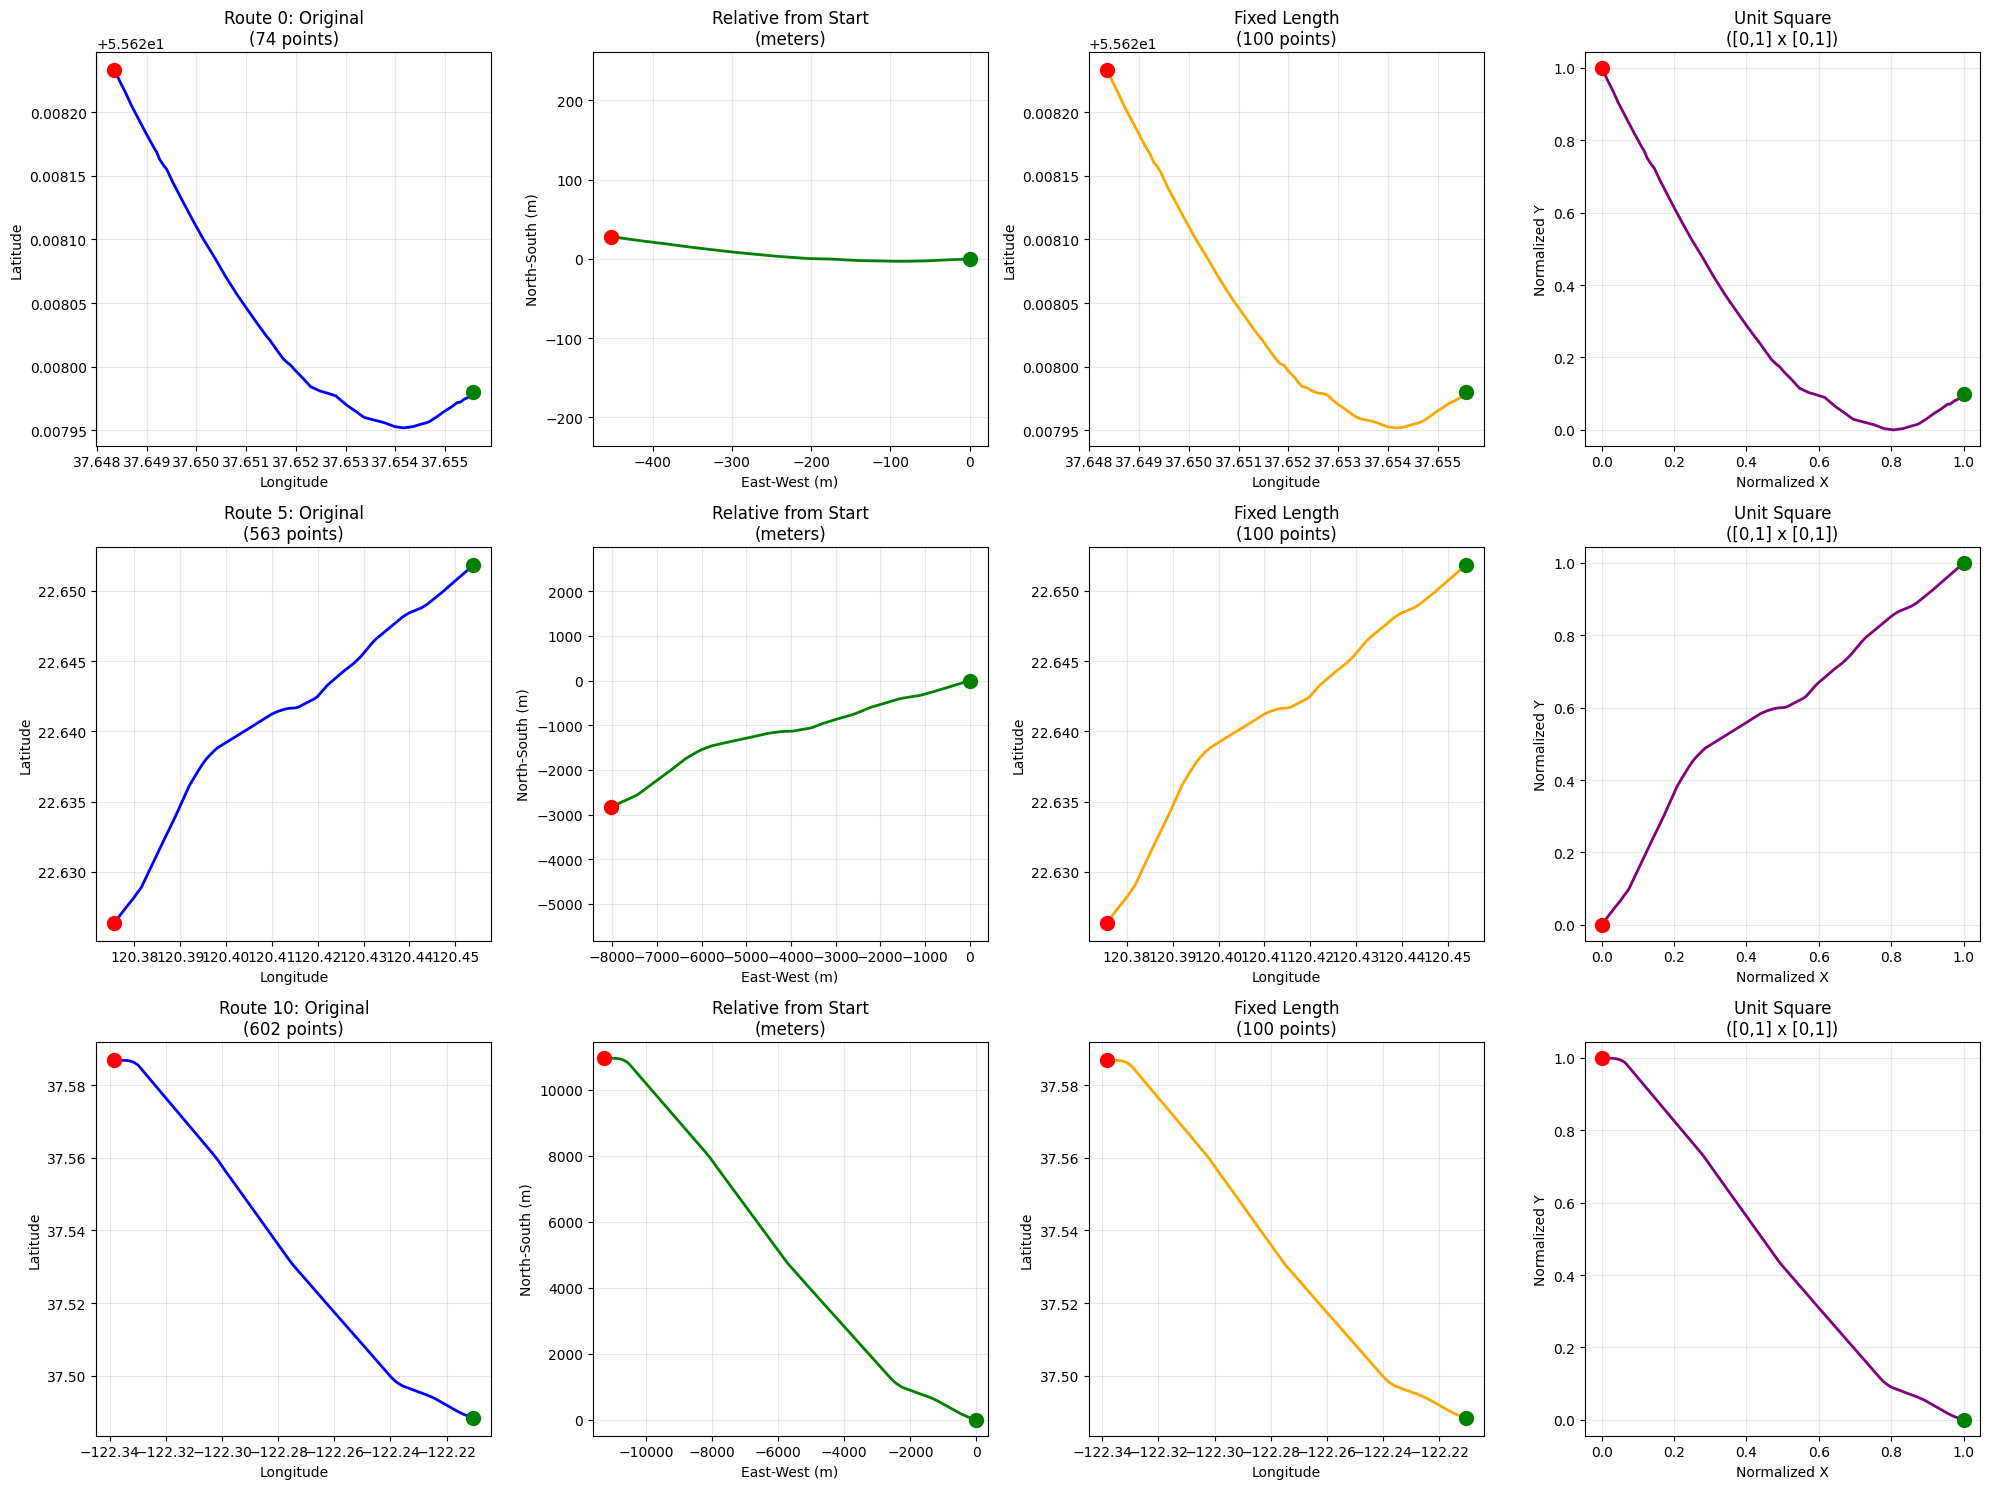

🎨 Visualization complete!
Green dot = Start, Red dot = End

Notice how:
- Column 1: Original routes in different locations
- Column 2: All start at (0,0), preserving actual distances
- Column 3: Resampled to same number of points
- Column 4: All scaled to fit in [0,1] x [0,1] square


In [23]:
import matplotlib.pyplot as plt

# Get 3 different routes
routes_to_compare = [0, 5, 10]
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for row_idx, route_idx in enumerate(routes_to_compare):
    route = get_data_by_index(route_idx)
    geometry = route.get('geometry', [])
    
    if not geometry:
        continue
    
    # Original
    ax = axes[row_idx, 0]
    lons = [p[0] for p in geometry]
    lats = [p[1] for p in geometry]
    ax.plot(lons, lats, 'b-', linewidth=2)
    ax.scatter(lons[0], lats[0], color='green', s=100, zorder=5)
    ax.scatter(lons[-1], lats[-1], color='red', s=100, zorder=5)
    ax.set_title(f'Route {route_idx}: Original\n({len(geometry)} points)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    
    # Method 1: Relative distances
    norm1 = normalize_route_relative(geometry)
    if norm1 is not None:
        ax = axes[row_idx, 1]
        ax.plot(norm1[:, 0], norm1[:, 1], 'g-', linewidth=2)
        ax.scatter(norm1[0, 0], norm1[0, 1], color='green', s=100, zorder=5)
        ax.scatter(norm1[-1, 0], norm1[-1, 1], color='red', s=100, zorder=5)
        ax.set_title(f'Relative from Start\n(meters)')
        ax.set_xlabel('East-West (m)')
        ax.set_ylabel('North-South (m)')
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    
    # Method 2: Fixed length (100 points)
    norm2 = normalize_route_fixed_length(geometry, n_points=100)
    if norm2 is not None:
        ax = axes[row_idx, 2]
        lons2 = norm2[:, 0]
        lats2 = norm2[:, 1]
        ax.plot(lons2, lats2, 'orange', linewidth=2)
        ax.scatter(lons2[0], lats2[0], color='green', s=100, zorder=5)
        ax.scatter(lons2[-1], lats2[-1], color='red', s=100, zorder=5)
        ax.set_title(f'Fixed Length\n(100 points)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(True, alpha=0.3)
    
    # Method 3: Unit square
    norm3 = normalize_route_unit_square(geometry)
    if norm3 is not None:
        ax = axes[row_idx, 3]
        ax.plot(norm3[:, 0], norm3[:, 1], 'purple', linewidth=2)
        ax.scatter(norm3[0, 0], norm3[0, 1], color='green', s=100, zorder=5)
        ax.scatter(norm3[-1, 0], norm3[-1, 1], color='red', s=100, zorder=5)
        ax.set_title(f'Unit Square\n([0,1] x [0,1])')
        ax.set_xlabel('Normalized X')
        ax.set_ylabel('Normalized Y')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)
        ax.axis('equal')

plt.tight_layout()
plt.show()

print("🎨 Visualization complete!")
print("Green dot = Start, Red dot = End")
print("\nNotice how:")
print("- Column 1: Original routes in different locations")
print("- Column 2: All start at (0,0), preserving actual distances")
print("- Column 3: Resampled to same number of points")
print("- Column 4: All scaled to fit in [0,1] x [0,1] square")

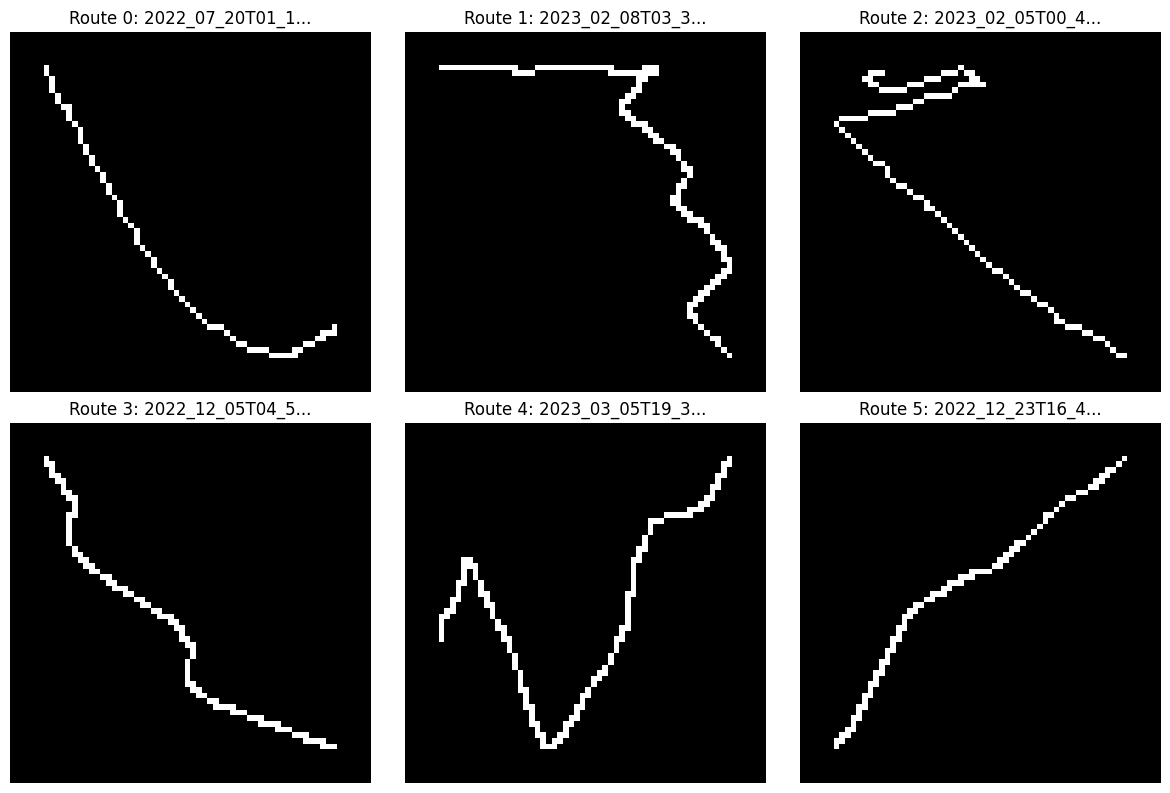

✅ Image conversion complete!
Image shape: (64, 64)

💡 These images can be fed directly into your Siamese CNN!
   - All routes are position-independent (relative coordinates)
   - Fixed 64x64 size
   - Ready for contrastive learning


In [30]:
# Image-based approach: Convert routes to binary images for CNN
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def route_to_image(geometry, img_size=64):
    """
    Convert a route to a binary image for CNN processing.
    Uses relative distances so position doesn't matter.
    """
    if not geometry or len(geometry) < 2:
        return None
    
    # Step 1: Normalize to relative distances from start
    norm_route = normalize_route_relative(geometry)
    
    # Step 2: Scale to fit in image (with padding)
    min_x, min_y = norm_route.min(axis=0)
    max_x, max_y = norm_route.max(axis=0)
    
    # Add 10% padding
    padding = 0.1
    range_x = max_x - min_x
    range_y = max_y - min_y
    
    if range_x == 0:
        range_x = 1
    if range_y == 0:
        range_y = 1
    
    # Scale to image coordinates
    scaled_x = ((norm_route[:, 0] - min_x) / range_x) * (img_size * (1 - 2*padding)) + img_size * padding
    scaled_y = ((norm_route[:, 1] - min_y) / range_y) * (img_size * (1 - 2*padding)) + img_size * padding
    
    # Create blank image
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    
    # Draw the route as connected lines
    for i in range(len(scaled_x) - 1):
        x1, y1 = int(scaled_x[i]), int(img_size - scaled_y[i])  # Flip Y
        x2, y2 = int(scaled_x[i+1]), int(img_size - scaled_y[i+1])
        
        # Draw line using Bresenham's algorithm (simple version)
        steps = max(abs(x2 - x1), abs(y2 - y1))
        if steps > 0:
            for t in range(steps + 1):
                x = int(x1 + (x2 - x1) * t / steps)
                y = int(y1 + (y2 - y1) * t / steps)
                if 0 <= x < img_size and 0 <= y < img_size:
                    img[y, x] = 255
    
    return img

# Test: Convert 6 different routes to images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    route = get_data_by_index(i)
    geometry = route.get('geometry', [])
    
    img = route_to_image(geometry, img_size=64)
    
    if img is not None:
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Route {i}: {route.get("Filename", "Unknown")[:15]}...')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

print("✅ Image conversion complete!")
print(f"Image shape: {img.shape if img is not None else 'N/A'}")
print("\n💡 These images can be fed directly into your Siamese CNN!")
print("   - All routes are position-independent (relative coordinates)")
print("   - Fixed 64x64 size")
print("   - Ready for contrastive learning")

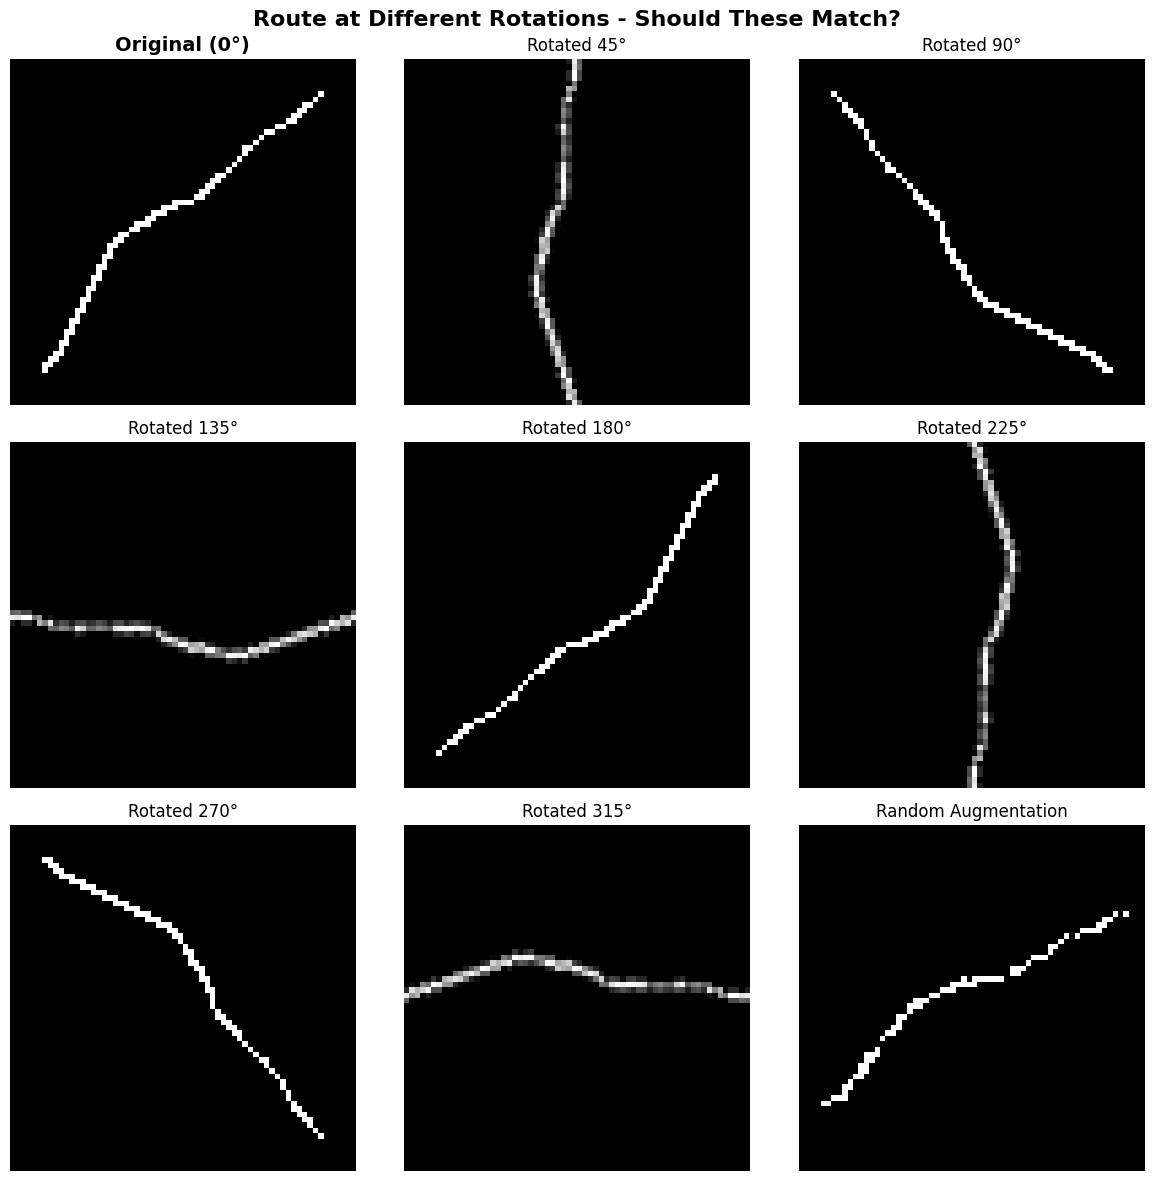

✅ Rotation demonstration complete!

🤔 Key Question: Should rotated versions be considered SIMILAR?
   - If YES → Use canonical orientation to align them first
   - If NO → Direction matters, keep them as different

💡 For running routes, shape usually matters more than direction:
   → Canonical orientation is recommended!
   → Then add small augmentations (±15°) for robustness


In [36]:
import torch
import torchvision.transforms as T
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Data augmentation for route images (to create positive pairs)
class RouteImageAugmentation:
    """
    Augmentation strategies for self-supervised learning on route images.
    Same route + different augmentations = positive pair
    """
    def __init__(self, img_size=64):
        self.img_size = img_size
        
        # Define augmentation pipeline
        self.transform = T.Compose([
            T.RandomRotation(degrees=15),  # Small rotation
            T.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1),  # Small shift
                scale=(0.9, 1.1),  # Small zoom
            ),
            T.RandomApply([
                T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
            ], p=0.3),
            T.RandomApply([
                T.Lambda(lambda x: self.add_noise(x))
            ], p=0.3),
            T.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Random dropout
        ])
    
    def add_noise(self, img_tensor):
        """Add Gaussian noise"""
        noise = torch.randn_like(img_tensor) * 0.1
        return torch.clamp(img_tensor + noise, 0, 1)
    
    def __call__(self, img_array):
        """
        Apply augmentation to numpy array
        Args:
            img_array: (H, W) numpy array (0-255)
        Returns:
            augmented tensor: (1, H, W) normalized to [0, 1]
        """
        # Convert to PIL Image
        pil_img = Image.fromarray(img_array)
        
        # Convert to tensor and normalize
        img_tensor = T.ToTensor()(pil_img)  # (1, H, W), [0, 1]
        
        # Apply augmentations
        augmented = self.transform(img_tensor)
        
        return augmented

# Test augmentation on a route
augmenter = RouteImageAugmentation(img_size=64)

# Get a route and convert to image
route = get_data_by_index(5)
geometry = route.get('geometry', [])
original_img = route_to_image(geometry, img_size=64)

# Show route with different rotations (to demonstrate rotation invariance need)
from scipy.ndimage import rotate as scipy_rotate

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Original
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original (0°)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# 8 different rotations: 45°, 90°, 135°, 180°, 225°, 270°, 315°, and one random augmentation
rotation_angles = [45, 90, 135, 180, 225, 270, 315]
for i, angle in enumerate(rotation_angles, start=1):
    rotated_img = scipy_rotate(original_img, angle, reshape=False, order=1)
    
    axes[i].imshow(rotated_img, cmap='gray')
    axes[i].set_title(f'Rotated {angle}°', fontsize=12)
    axes[i].axis('off')

# Last one: show a random augmentation with other transforms
aug_tensor = augmenter(original_img)
aug_img = aug_tensor.squeeze().numpy()
axes[8].imshow(aug_img, cmap='gray')
axes[8].set_title('Random Augmentation', fontsize=12)
axes[8].axis('off')

plt.suptitle('Route at Different Rotations - Should These Match?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Rotation demonstration complete!")
print("\n🤔 Key Question: Should rotated versions be considered SIMILAR?")
print("   - If YES → Use canonical orientation to align them first")
print("   - If NO → Direction matters, keep them as different")
print("\n💡 For running routes, shape usually matters more than direction:")
print("   → Canonical orientation is recommended!")
print("   → Then add small augmentations (±15°) for robustness")

In [38]:
import torch.nn as nn
import torch.nn.functional as F
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        euclidean_distance = F.pairwise_distance(output1, output2)
        
        # Calculate loss
        # Label 0: Similar (pull together) -> minimize distance
        # Label 1: Dissimilar (push apart) -> maximize distance up to margin
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

In [39]:
# Simple CNN for route image embedding
import torch.nn as nn
import torch.nn.functional as F

class RouteCNN(nn.Module):
    """
    Simple CNN to extract features from route images.
    Input: (batch, 1, 64, 64) grayscale route images
    Output: (batch, 128) embedding vectors
    """
    def __init__(self, embedding_dim=128):
        super(RouteCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 64 -> 32
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 32 -> 16
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 16 -> 8
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, embedding_dim)
    
    def forward(self, x):
        # Convolutional layers with ReLU and pooling
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        # L2 normalization for better contrastive learning
        x = F.normalize(x, p=2, dim=1)
        
        return x

# Test the network
model = RouteCNN(embedding_dim=128)
print(f"✅ Model created!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test with a dummy input
dummy_input = torch.randn(4, 1, 64, 64)  # Batch of 4 images
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min().item():.3f}, {output.max().item():.3f}]")

print("\n📊 Model architecture:")
print(model)

✅ Model created!
Total parameters: 4,354,112

Input shape: torch.Size([4, 1, 64, 64])
Output shape: torch.Size([4, 128])
Output range: [-0.314, 0.252]

📊 Model architecture:
RouteCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=Tr

In [40]:
# PyTorch Dataset for route pairs
from torch.utils.data import Dataset, DataLoader

class RouteDataset(Dataset):
    """
    Dataset for contrastive learning on route images.
    Returns pairs of images with labels:
    - Label 0: Same route (positive pair)
    - Label 1: Different routes (negative pair)
    """
    def __init__(self, jsonl_path, num_routes=1000, augmenter=None):
        self.jsonl_path = jsonl_path
        self.num_routes = num_routes
        self.augmenter = augmenter or RouteImageAugmentation()
        
        print(f"Loading {num_routes} routes...")
        self.routes = []
        with open(jsonl_path, 'r') as f:
            for i, line in enumerate(f):
                if i >= num_routes:
                    break
                route = json.loads(line)
                geometry = route.get('geometry', [])
                if geometry and len(geometry) >= 2:
                    # Convert to image immediately
                    img = route_to_image(geometry, img_size=64)
                    if img is not None:
                        self.routes.append(img)
        
        print(f"✅ Loaded {len(self.routes)} valid routes")
    
    def __len__(self):
        # Each epoch we generate synthetic pairs
        return len(self.routes) * 2  # 2x because we make 1 positive + 1 negative per route
    
    def __getitem__(self, idx):
        # 50% chance: positive pair (same route, different augmentations)
        # 50% chance: negative pair (different routes)
        
        if idx % 2 == 0:
            # Positive pair: same route with 2 different augmentations
            route_idx = (idx // 2) % len(self.routes)
            img = self.routes[route_idx]
            
            # Apply 2 different augmentations
            img1_tensor = self.augmenter(img)
            img2_tensor = self.augmenter(img)
            
            label = torch.tensor(0.0)  # 0 = similar
        else:
            # Negative pair: 2 different routes
            route_idx1 = (idx // 2) % len(self.routes)
            route_idx2 = (route_idx1 + np.random.randint(1, len(self.routes))) % len(self.routes)
            
            img1 = self.routes[route_idx1]
            img2 = self.routes[route_idx2]
            
            # Apply augmentation to each
            img1_tensor = self.augmenter(img1)
            img2_tensor = self.augmenter(img2)
            
            label = torch.tensor(1.0)  # 1 = dissimilar
        
        return img1_tensor, img2_tensor, label

# Create dataset and dataloader
dataset = RouteDataset("WorldTrace_20k.jsonl", num_routes=1000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\n📦 Dataset ready!")
print(f"   Total samples per epoch: {len(dataset)}")
print(f"   Batches per epoch: {len(dataloader)}")
print(f"   Batch size: 32")

# Test the dataloader
img1, img2, labels = next(iter(dataloader))
print(f"\n🔍 Sample batch:")
print(f"   Image 1 shape: {img1.shape}")
print(f"   Image 2 shape: {img2.shape}")
print(f"   Labels shape: {labels.shape}")
print(f"   Positive pairs: {(labels == 0).sum().item()}")
print(f"   Negative pairs: {(labels == 1).sum().item()}")

Loading 1000 routes...
✅ Loaded 1000 valid routes

📦 Dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63
   Batch size: 32

🔍 Sample batch:
   Image 1 shape: torch.Size([32, 1, 64, 64])
   Image 2 shape: torch.Size([32, 1, 64, 64])
   Labels shape: torch.Size([32])
   Positive pairs: 10
   Negative pairs: 22
✅ Loaded 1000 valid routes

📦 Dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63
   Batch size: 32

🔍 Sample batch:
   Image 1 shape: torch.Size([32, 1, 64, 64])
   Image 2 shape: torch.Size([32, 1, 64, 64])
   Labels shape: torch.Size([32])
   Positive pairs: 10
   Negative pairs: 22


🖥️  Using device: cpu

🚀 Starting training for 5 epochs...


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.6108


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 0.5254


...

Epoch 3/5 - Loss: 0.4735


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.4069


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.4310

✅ Training complete!


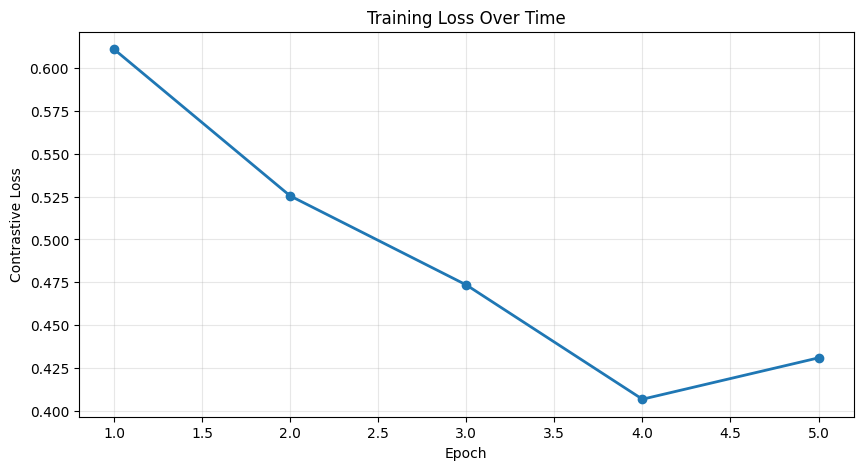


Final loss: 0.4310


In [41]:
# Training loop with contrastive loss
import torch.optim as optim
from tqdm.auto import tqdm

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

# Initialize model, loss, and optimizer
model = RouteCNN(embedding_dim=128).to(device)
criterion = ContrastiveLoss(margin=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for img1, img2, labels in tqdm(dataloader, desc="Training"):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        output1 = model(img1)
        output2 = model(img2)
        
        # Calculate loss
        loss = criterion(output1, output2, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Train for a few epochs
num_epochs = 5
print(f"\n🚀 Starting training for {num_epochs} epochs...")
print("=" * 60)

history = {'loss': []}

for epoch in range(num_epochs):
    avg_loss = train_epoch(model, dataloader, criterion, optimizer, device)
    history['loss'].append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("\n✅ Training complete!")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), history['loss'], marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {history['loss'][-1]:.4f}")

🔍 Finding similar routes using the trained model...
Computing embeddings for all routes...
✅ Generated 1000 embeddings

📍 Query Route: #0
Finding 5 most similar routes...

✅ Generated 1000 embeddings

📍 Query Route: #0
Finding 5 most similar routes...



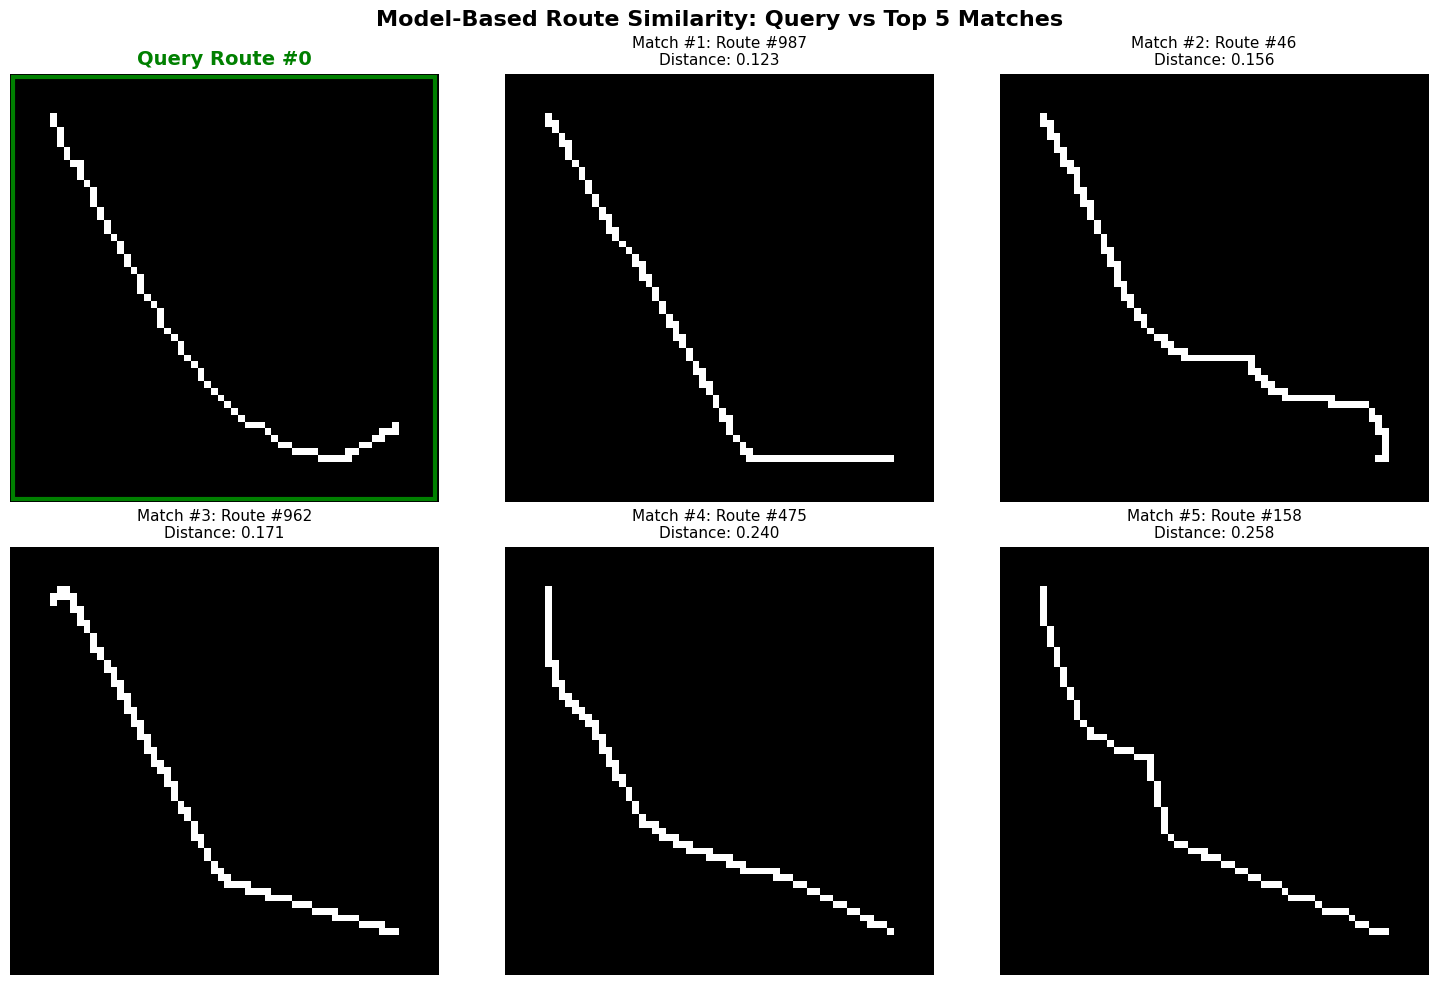

📊 Similarity Results:
   Query: Route #0
   1. Route #987 - Distance: 0.123
   2. Route #46 - Distance: 0.156
   3. Route #962 - Distance: 0.171
   4. Route #475 - Distance: 0.240
   5. Route #158 - Distance: 0.258

💡 Interpretation:
   - Lower distance = more similar route shapes
   - The model learned to identify similar patterns!
   - Distances are in embedding space (not pixels)


In [43]:
# Test the trained model: Find most similar routes
print("🔍 Finding similar routes using the trained model...")

# Get embeddings for all routes
model.eval()
embeddings = []

print("Computing embeddings for all routes...")
with torch.no_grad():
    for i in range(len(dataset.routes)):
        img = dataset.routes[i]
        # Convert to tensor
        img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(device)
        
        # Get embedding
        embedding = model(img_tensor)
        embeddings.append(embedding.cpu().numpy())

embeddings = np.vstack(embeddings)
print(f"✅ Generated {len(embeddings)} embeddings")

# Pick the first route as query
query_idx = 0
query_embedding = embeddings[query_idx]

# Compute distances to all other routes
distances = np.linalg.norm(embeddings - query_embedding, axis=1)

# Get top 5 most similar routes (excluding itself)
most_similar_indices = np.argsort(distances)[1:6]  # Skip index 0 (itself)

print(f"\n📍 Query Route: #{query_idx}")
print(f"Finding 5 most similar routes...\n")

# Visualize the query route and its 5 most similar matches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot query route
axes[0].imshow(dataset.routes[query_idx], cmap='gray')
axes[0].set_title(f'Query Route #{query_idx}', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')
axes[0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))

# Plot 5 most similar routes
for i, similar_idx in enumerate(most_similar_indices, start=1):
    axes[i].imshow(dataset.routes[similar_idx], cmap='gray')
    distance = distances[similar_idx]
    axes[i].set_title(f'Match #{i}: Route #{similar_idx}\nDistance: {distance:.3f}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Model-Based Route Similarity: Query vs Top 5 Matches', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Similarity Results:")
print(f"   Query: Route #{query_idx}")
for rank, similar_idx in enumerate(most_similar_indices, start=1):
    distance = distances[similar_idx]
    print(f"   {rank}. Route #{similar_idx} - Distance: {distance:.3f}")

print("\n💡 Interpretation:")
print("   - Lower distance = more similar route shapes")
print("   - The model learned to identify similar patterns!")
print("   - Distances are in embedding space (not pixels)")

🔍 Finding similar routes for first 10 query routes...
✅ Processed 10 query routes



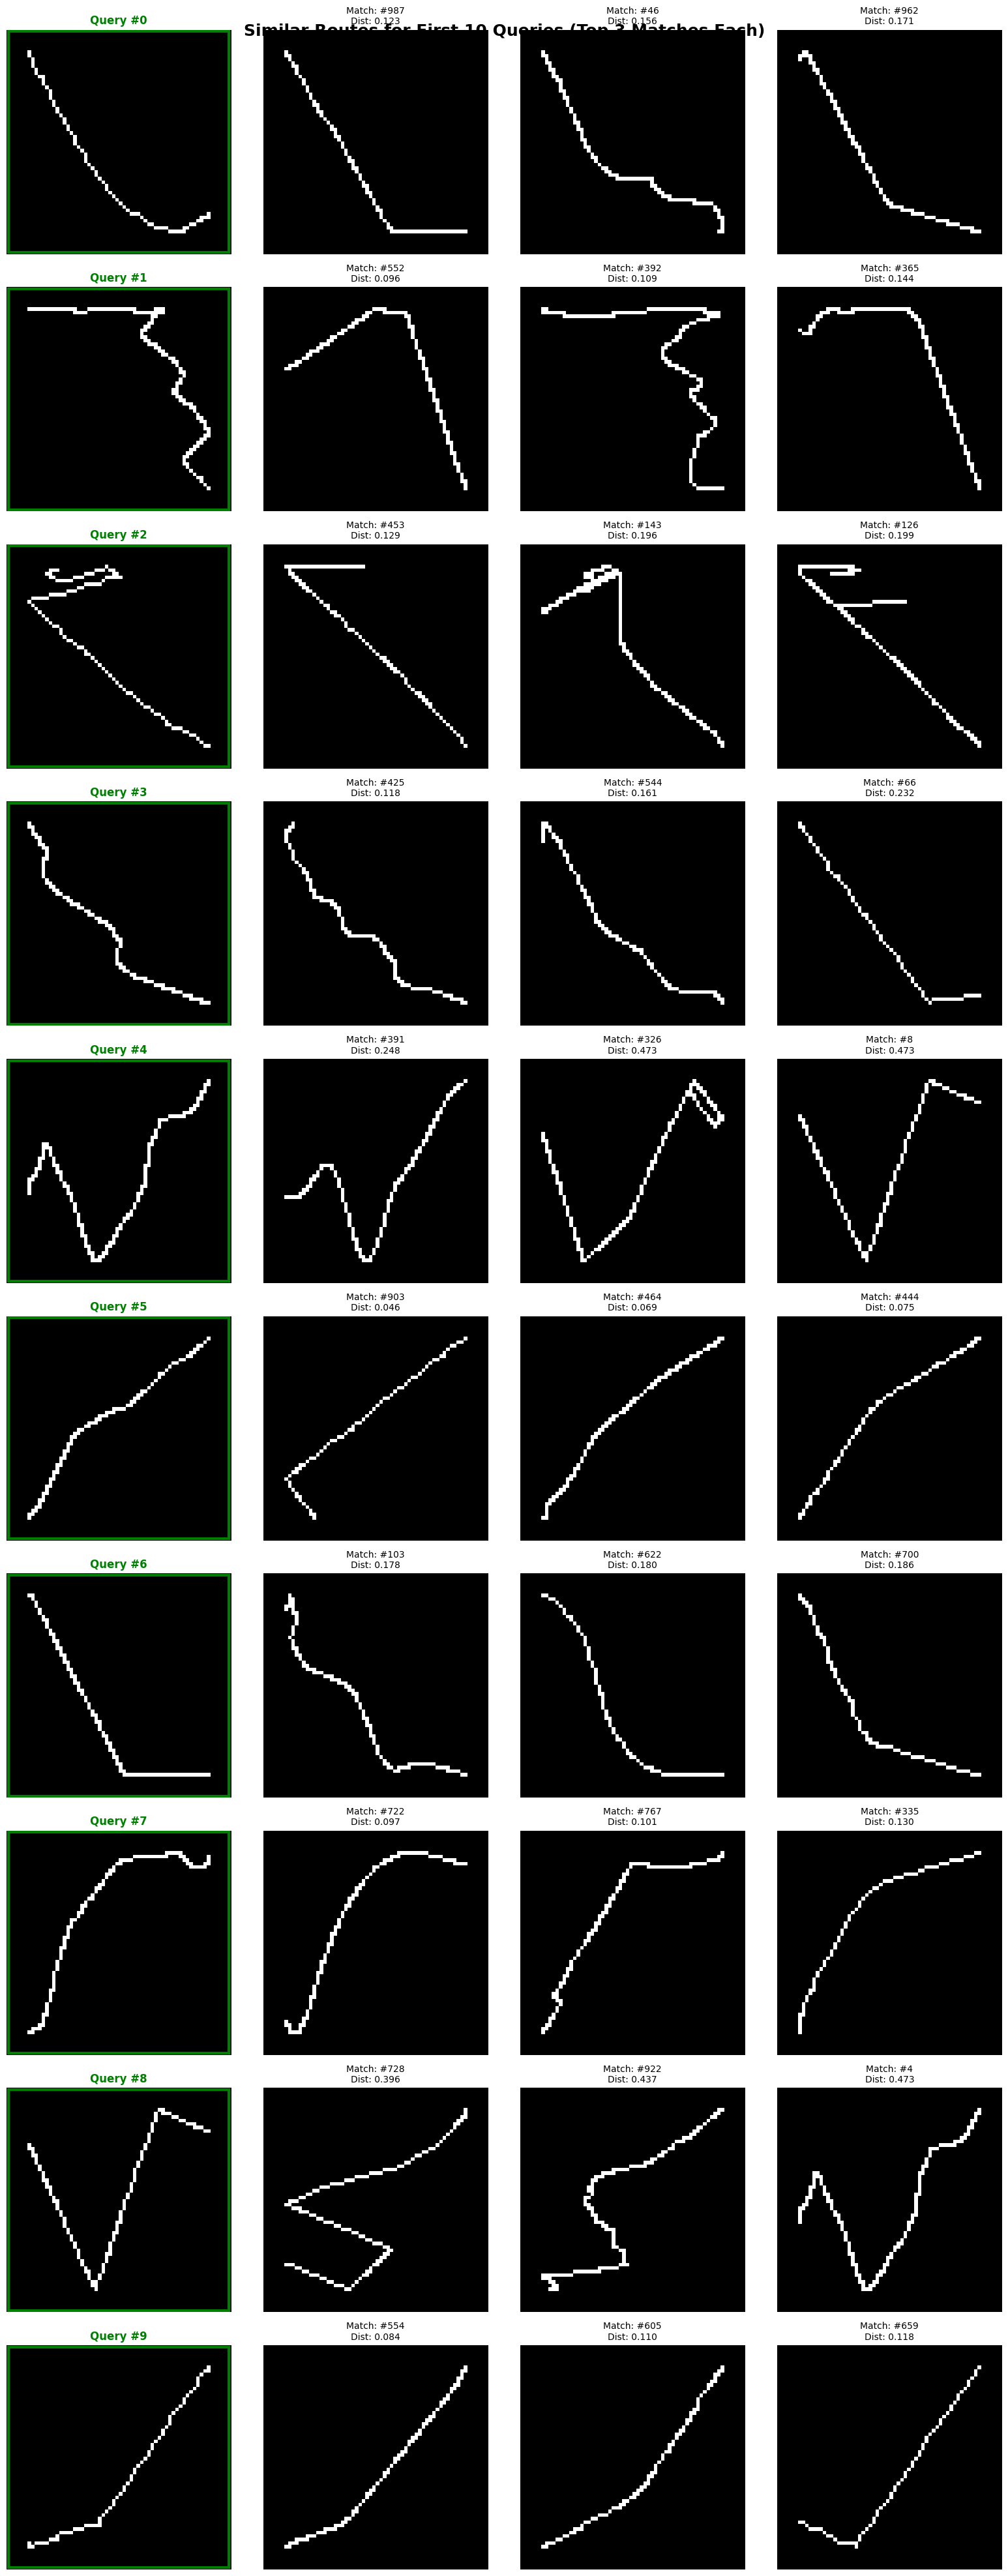


📊 Similarity Summary:

Query Route #0:
   1. Route #987 - Distance: 0.123
   2. Route #46 - Distance: 0.156
   3. Route #962 - Distance: 0.171

Query Route #1:
   1. Route #552 - Distance: 0.096
   2. Route #392 - Distance: 0.109
   3. Route #365 - Distance: 0.144

Query Route #2:
   1. Route #453 - Distance: 0.129
   2. Route #143 - Distance: 0.196
   3. Route #126 - Distance: 0.199

Query Route #3:
   1. Route #425 - Distance: 0.118
   2. Route #544 - Distance: 0.161
   3. Route #66 - Distance: 0.232

Query Route #4:
   1. Route #391 - Distance: 0.248
   2. Route #326 - Distance: 0.473
   3. Route #8 - Distance: 0.473

Query Route #5:
   1. Route #903 - Distance: 0.046
   2. Route #464 - Distance: 0.069
   3. Route #444 - Distance: 0.075

Query Route #6:
   1. Route #103 - Distance: 0.178
   2. Route #622 - Distance: 0.180
   3. Route #700 - Distance: 0.186

Query Route #7:
   1. Route #722 - Distance: 0.097
   2. Route #767 - Distance: 0.101
   3. Route #335 - Distance: 0.130

Quer

In [44]:
# Find similar routes for first 10 routes
print("🔍 Finding similar routes for first 10 query routes...")

# We already have embeddings for all routes from previous cell
# Just recompute if needed
if 'embeddings' not in locals():
    model.eval()
    embeddings = []
    print("Computing embeddings for all routes...")
    with torch.no_grad():
        for i in range(len(dataset.routes)):
            img = dataset.routes[i]
            img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
            img_tensor = img_tensor.to(device)
            embedding = model(img_tensor)
            embeddings.append(embedding.cpu().numpy())
    embeddings = np.vstack(embeddings)

# Process first 10 routes
num_queries = 10
results = []

for query_idx in range(num_queries):
    query_embedding = embeddings[query_idx]
    
    # Compute distances to all other routes
    distances = np.linalg.norm(embeddings - query_embedding, axis=1)
    
    # Get top 3 most similar routes (excluding itself)
    most_similar_indices = np.argsort(distances)[1:4]  # Top 3 matches
    
    results.append({
        'query_idx': query_idx,
        'matches': most_similar_indices,
        'distances': distances[most_similar_indices]
    })

print(f"✅ Processed {num_queries} query routes\n")

# Visualize all results in a grid
fig, axes = plt.subplots(num_queries, 4, figsize=(16, 4*num_queries))

for row, result in enumerate(results):
    query_idx = result['query_idx']
    matches = result['matches']
    match_distances = result['distances']
    
    # Column 0: Query route
    axes[row, 0].imshow(dataset.routes[query_idx], cmap='gray')
    axes[row, 0].set_title(f'Query #{query_idx}', fontsize=12, fontweight='bold', color='green')
    axes[row, 0].axis('off')
    axes[row, 0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))
    
    # Columns 1-3: Top 3 matches
    for col, (match_idx, dist) in enumerate(zip(matches, match_distances), start=1):
        axes[row, col].imshow(dataset.routes[match_idx], cmap='gray')
        axes[row, col].set_title(f'Match: #{match_idx}\nDist: {dist:.3f}', fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('Similar Routes for First 10 Queries (Top 3 Matches Each)', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n📊 Similarity Summary:")
print("=" * 60)
for result in results:
    query_idx = result['query_idx']
    matches = result['matches']
    match_distances = result['distances']
    
    print(f"\nQuery Route #{query_idx}:")
    for rank, (match_idx, dist) in enumerate(zip(matches, match_distances), start=1):
        print(f"   {rank}. Route #{match_idx} - Distance: {dist:.3f}")

print("\n💡 Lower distances indicate more similar route shapes!")

In [46]:
print(get_data_by_index(1))


{'Filename': '2023_02_08T03_37_45.045645Z.gpx', 'Uploaded': ' 9 February 2023 at 03:50', 'Points': 600, 'Start coordinate': ['42.34847039209213', '-71.10443325547672'], 'Owner': 'sunnypilot', 'Description': 'Routes from sunnypilot 2022.12.16 (HYUNDAI SANTA FE 2022).', 'Tags': 'None', 'Visibility': 'Identifiable (shown in trace list and as identifiable, ordered points with timestamps)', 'Distance': 15028.128753511506, 'Time': 599.0, 'geometry': [[-71.104441, 42.348447], [-71.104221, 42.348405], [-71.104026, 42.348368], [-71.104004, 42.348363], [-71.103788, 42.348322], [-71.103572, 42.348281], [-71.103354, 42.348239], [-71.103136, 42.348197], [-71.102919, 42.348156], [-71.102705, 42.348115], [-71.102494, 42.348075], [-71.102291, 42.348036], [-71.102099, 42.347999], [-71.101922, 42.347965], [-71.101839, 42.34795], [-71.101757, 42.347935], [-71.101598, 42.347906], [-71.101558, 42.347899], [-71.101438, 42.347879], [-71.101278, 42.347853], [-71.101259, 42.34785], [-71.101111, 42.347834], [-7

In [ ]:
print(get_data_by_index(0))

{'Filename': '2022_07_20T01_18_27.591242Z.gpx', 'Uploaded': '22 July 2023 at 05:52', 'Points': 58, 'Start coordinate': ['55.627981623288896', '37.65556577791681'], 'Owner': 'dragonpilot', 'Description': 'Routes from dragonpilot 2023.04.13 (VOLKSWAGEN TIGUAN 2ND GEN).', 'Tags': 'None', 'Visibility': 'Identifiable (shown in trace list and as identifiable, ordered points with timestamps)', 'Distance': 455.6308553917523, 'Time': 178, 'geometry': [[37.655566, 55.62798], [37.655565, 55.627979], [37.655559, 55.627979], [37.655554, 55.627979], [37.655552, 55.627979], [37.655549, 55.627979], [37.65554, 55.627979], [37.655526, 55.627978], [37.655503, 55.627977], [37.655464, 55.627976], [37.655419, 55.627975], [37.655406, 55.627975], [37.655366, 55.627974], [37.655299, 55.627972], [37.65525, 55.627972], [37.655216, 55.627971], [37.655112, 55.627968], [37.654986, 55.627965], [37.654846, 55.627961], [37.654689, 55.627957], [37.65463, 55.627956], [37.654526, 55.627955], [37.654361, 55.627953], [37.6

📊 Loading routes to analyze distributions...
✅ Loaded 20000 routes with terrain data
✅ Loaded 20000 routes with terrain data


/var/folders/m3/2m8_fl_d4ddgncptvm0qqhsh0000gn/T/ipykernel_79102/1358476772.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(pace_data, labels=terrain_names, patch_artist=True)


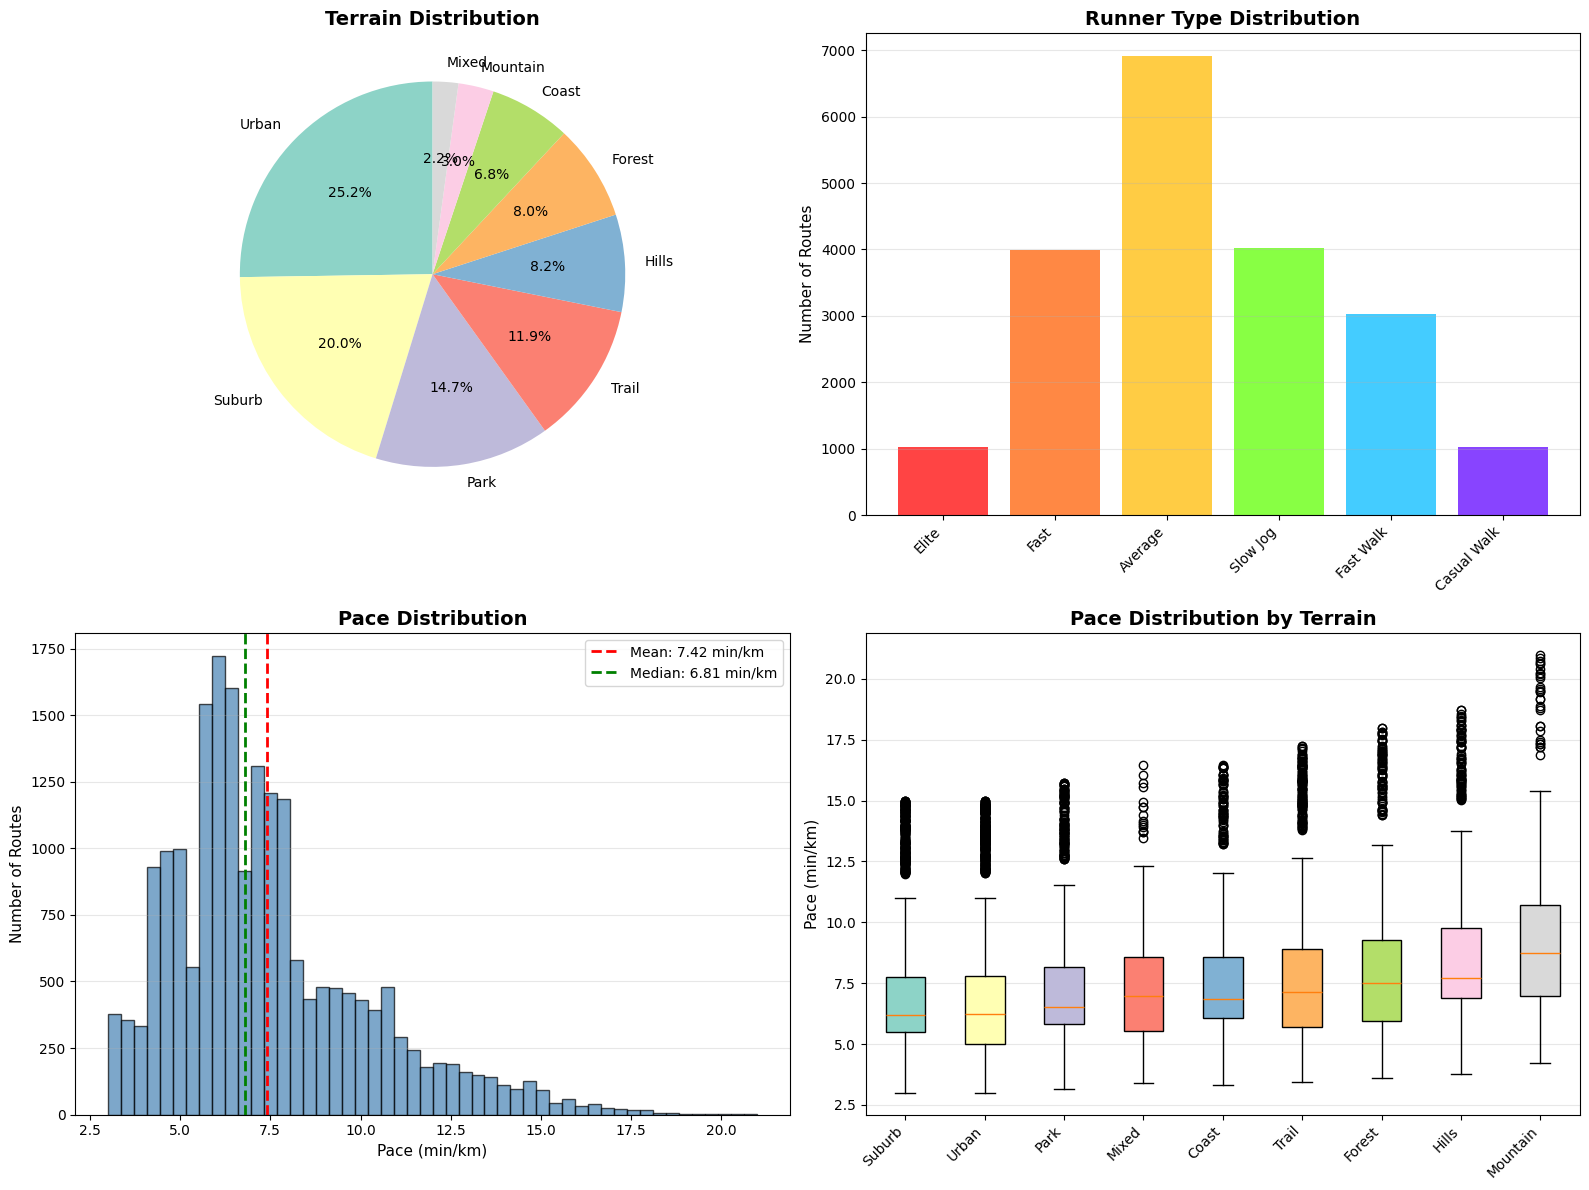


📈 DISTRIBUTION STATISTICS

🌍 Terrain Distribution:
   Urban       :  5049 routes ( 25.2%)
   Suburb      :  4001 routes ( 20.0%)
   Park        :  2933 routes ( 14.7%)
   Trail       :  2386 routes ( 11.9%)
   Hills       :  1632 routes (  8.2%)
   Forest      :  1608 routes (  8.0%)
   Coast       :  1367 routes (  6.8%)
   Mountain    :   593 routes (  3.0%)
   Mixed       :   431 routes (  2.2%)

🏃 Runner Type Distribution:
   Elite          :  1022 routes (  5.1%)
   Fast           :  3993 routes ( 20.0%)
   Average        :  6909 routes ( 34.5%)
   Slow Jog       :  4022 routes ( 20.1%)
   Fast Walk      :  3022 routes ( 15.1%)
   Casual Walk    :  1032 routes (  5.2%)

⚡ Pace Statistics:
   Mean:   7.42 min/km
   Median: 6.81 min/km
   Min:    3.00 min/km
   Max:    20.99 min/km
   Std:    2.75 min/km

🏔️  Average Pace by Terrain:
   Suburb      : 6.85 min/km
   Urban       : 6.88 min/km
   Park        : 7.19 min/km
   Mixed       : 7.51 min/km
   Coast       : 7.55 min/km
   Tr

In [55]:
# Visualize terrain and running speed distributions
import matplotlib.pyplot as plt
import json
import numpy as np

print("📊 Loading routes to analyze distributions...")

# Load all routes
terrains = []
runner_types = []
paces = []
distances = []

with open('WorldTrace_20k.jsonl', 'r') as f:
    for line in f:
        route = json.loads(line)
        if 'Terrain' in route:
            terrains.append(route['Terrain'])
        if 'RunnerType' in route:
            runner_types.append(route['RunnerType'])
        if 'PaceMinPerKm' in route:
            paces.append(route['PaceMinPerKm'])
        if 'Distance' in route:
            distances.append(route['Distance'] / 1000.0)  # Convert to km

print(f"✅ Loaded {len(terrains)} routes with terrain data")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Terrain Distribution (Pie Chart)
if terrains:
    terrain_counts = {}
    for t in terrains:
        terrain_counts[t] = terrain_counts.get(t, 0) + 1
    
    sorted_terrains = sorted(terrain_counts.items(), key=lambda x: x[1], reverse=True)
    terrain_labels = [t[0].title() for t in sorted_terrains]
    terrain_values = [t[1] for t in sorted_terrains]
    
    colors = plt.cm.Set3(range(len(terrain_labels)))
    
    axes[0, 0].pie(terrain_values, labels=terrain_labels, autopct='%1.1f%%',
                   colors=colors, startangle=90)
    axes[0, 0].set_title('Terrain Distribution', fontsize=14, fontweight='bold')

# 2. Runner Type Distribution (Bar Chart)
if runner_types:
    runner_counts = {}
    for rt in runner_types:
        runner_counts[rt] = runner_counts.get(rt, 0) + 1
    
    sorted_runners = sorted(runner_counts.items(), 
                           key=lambda x: ['elite', 'fast', 'average', 'slow_jog', 'fast_walk', 'casual_walk'].index(x[0]) 
                           if x[0] in ['elite', 'fast', 'average', 'slow_jog', 'fast_walk', 'casual_walk'] else 999)
    
    runner_labels = [r[0].replace('_', ' ').title() for r in sorted_runners]
    runner_values = [r[1] for r in sorted_runners]
    
    colors_runner = ['#ff4444', '#ff8844', '#ffcc44', '#88ff44', '#44ccff', '#8844ff'][:len(runner_labels)]
    
    axes[0, 1].bar(range(len(runner_labels)), runner_values, color=colors_runner)
    axes[0, 1].set_xticks(range(len(runner_labels)))
    axes[0, 1].set_xticklabels(runner_labels, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Number of Routes', fontsize=11)
    axes[0, 1].set_title('Runner Type Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Pace Distribution (Histogram)
if paces:
    axes[1, 0].hist(paces, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Pace (min/km)', fontsize=11)
    axes[1, 0].set_ylabel('Number of Routes', fontsize=11)
    axes[1, 0].set_title('Pace Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].axvline(np.mean(paces), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(paces):.2f} min/km')
    axes[1, 0].axvline(np.median(paces), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(paces):.2f} min/km')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Pace by Terrain (Box Plot)
if terrains and paces:
    # Group paces by terrain
    terrain_pace_data = {}
    
    with open('WorldTrace_20k.jsonl', 'r') as f:
        for line in f:
            route = json.loads(line)
            if 'Terrain' in route and 'PaceMinPerKm' in route:
                terrain = route['Terrain']
                pace = route['PaceMinPerKm']
                if terrain not in terrain_pace_data:
                    terrain_pace_data[terrain] = []
                terrain_pace_data[terrain].append(pace)
    
    # Sort by average pace
    sorted_terrain_pace = sorted(terrain_pace_data.items(), 
                                 key=lambda x: np.mean(x[1]))
    
    terrain_names = [t[0].title() for t in sorted_terrain_pace]
    pace_data = [t[1] for t in sorted_terrain_pace]
    
    bp = axes[1, 1].boxplot(pace_data, labels=terrain_names, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(terrain_names)))):
        patch.set_facecolor(color)
    
    axes[1, 1].set_xticklabels(terrain_names, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Pace (min/km)', fontsize=11)
    axes[1, 1].set_title('Pace Distribution by Terrain', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 70)
print("📈 DISTRIBUTION STATISTICS")
print("=" * 70)

if terrains:
    print("\n🌍 Terrain Distribution:")
    for terrain, count in sorted_terrains:
        pct = (count / len(terrains)) * 100
        print(f"   {terrain.title():12s}: {count:5d} routes ({pct:5.1f}%)")

if runner_types:
    print("\n🏃 Runner Type Distribution:")
    for runner, count in sorted_runners:
        pct = (count / len(runner_types)) * 100
        print(f"   {runner.replace('_', ' ').title():15s}: {count:5d} routes ({pct:5.1f}%)")

if paces:
    print(f"\n⚡ Pace Statistics:")
    print(f"   Mean:   {np.mean(paces):.2f} min/km")
    print(f"   Median: {np.median(paces):.2f} min/km")
    print(f"   Min:    {np.min(paces):.2f} min/km")
    print(f"   Max:    {np.max(paces):.2f} min/km")
    print(f"   Std:    {np.std(paces):.2f} min/km")

if terrain_pace_data:
    print(f"\n🏔️  Average Pace by Terrain:")
    for terrain, paces_list in sorted_terrain_pace:
        avg_pace = np.mean(paces_list)
        print(f"   {terrain.title():12s}: {avg_pace:.2f} min/km")

print("\n" + "=" * 70)

In [62]:
# Metadata MLP model for pace, terrain, and distance
import torch
import torch.nn as nn
import torch.nn.functional as F

class MetadataMLP(nn.Module):
    """
    MLP to encode route metadata: pace, terrain, distance
    Output: (batch, 128) embedding vectors (same dim as CNN)
    """
    def __init__(self, embedding_dim=128, num_terrains=9):
        super(MetadataMLP, self).__init__()
        
        # Terrain will be one-hot encoded (9 categories)
        # Input: pace (1) + terrain (9) + distance (1) = 11 features
        input_dim = 1 + num_terrains + 1
        
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, embedding_dim)
        
    def forward(self, pace, terrain_onehot, distance):
        """
        Args:
            pace: (batch, 1) - pace in min/km
            terrain_onehot: (batch, 9) - one-hot encoded terrain
            distance: (batch, 1) - distance in km
        Returns:
            embedding: (batch, 128)
        """
        # Concatenate all features
        x = torch.cat([pace, terrain_onehot, distance], dim=1)
        
        # Layer 1
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        # Layer 2
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        # Layer 3
        x = self.fc3(x)
        
        # L2 normalization
        x = F.normalize(x, p=2, dim=1)
        
        return x

# Test the metadata model
metadata_model = MetadataMLP(embedding_dim=128, num_terrains=9)
print(f"✅ Metadata MLP created!")
print(f"Total parameters: {sum(p.numel() for p in metadata_model.parameters()):,}")

# Test with dummy data
dummy_pace = torch.randn(4, 1) * 3 + 6  # Around 6 min/km
dummy_terrain = torch.zeros(4, 9)
dummy_terrain[:, 0] = 1  # First terrain type
dummy_distance = torch.randn(4, 1) * 2 + 5  # Around 5 km

output = metadata_model(dummy_pace, dummy_terrain, dummy_distance)
print(f"\nInput shapes:")
print(f"  Pace: {dummy_pace.shape}")
print(f"  Terrain (one-hot): {dummy_terrain.shape}")
print(f"  Distance: {dummy_distance.shape}")
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min().item():.3f}, {output.max().item():.3f}]")

print("\n📊 Metadata MLP architecture:")
print(metadata_model)

✅ Metadata MLP created!
Total parameters: 102,784

Input shapes:
  Pace: torch.Size([4, 1])
  Terrain (one-hot): torch.Size([4, 9])
  Distance: torch.Size([4, 1])
Output shape: torch.Size([4, 128])
Output range: [-0.255, 0.217]

📊 Metadata MLP architecture:
MetadataMLP(
  (fc1): Linear(in_features=11, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
)


In [60]:
# Dataset for metadata contrastive learning
from torch.utils.data import Dataset, DataLoader
import json

class MetadataDataset(Dataset):
    """
    Dataset for contrastive learning on route metadata.
    Returns pairs with labels:
    - Label 0: Similar metadata (positive pair)
    - Label 1: Different metadata (negative pair)
    """
    def __init__(self, jsonl_path, num_routes=1000):
        self.jsonl_path = jsonl_path
        self.num_routes = num_routes
        
        # Terrain mapping
        self.terrain_to_idx = {
            'urban': 0, 'suburb': 1, 'park': 2, 'trail': 3,
            'forest': 4, 'coast': 5, 'hills': 6, 'mountain': 7, 'mixed': 8
        }
        
        print(f"Loading {num_routes} routes with metadata...")
        self.routes = []
        
        with open(jsonl_path, 'r') as f:
            for i, line in enumerate(f):
                if i >= num_routes:
                    break
                route = json.loads(line)
                
                # Extract metadata
                if ('PaceMinPerKm' in route and 'Terrain' in route and 
                    'Distance' in route and route['Distance'] > 0):
                    
                    pace = route['PaceMinPerKm']
                    terrain = route['Terrain']
                    distance = route['Distance'] / 1000.0  # Convert to km
                    
                    if terrain in self.terrain_to_idx:
                        self.routes.append({
                            'pace': pace,
                            'terrain': terrain,
                            'distance': distance
                        })
        
        print(f"✅ Loaded {len(self.routes)} valid routes with metadata")
    
    def terrain_to_onehot(self, terrain):
        """Convert terrain string to one-hot vector"""
        onehot = torch.zeros(9)
        if terrain in self.terrain_to_idx:
            onehot[self.terrain_to_idx[terrain]] = 1.0
        return onehot
    
    def __len__(self):
        return len(self.routes) * 2
    
    def __getitem__(self, idx):
        # 50% positive pairs (similar metadata)
        # 50% negative pairs (different metadata)
        
        if idx % 2 == 0:
            # Positive pair: routes with similar pace and terrain
            route_idx = (idx // 2) % len(self.routes)
            route1 = self.routes[route_idx]
            
            # Find a route with similar characteristics
            # Similar = same terrain OR similar pace (within 1 min/km)
            similar_candidates = []
            for i, r in enumerate(self.routes):
                if i != route_idx:
                    # Same terrain or similar pace
                    if (r['terrain'] == route1['terrain'] or 
                        abs(r['pace'] - route1['pace']) < 1.5):
                        similar_candidates.append(i)
            
            if similar_candidates:
                route2_idx = np.random.choice(similar_candidates)
                route2 = self.routes[route2_idx]
            else:
                # Fallback: just pick a nearby route
                route2_idx = (route_idx + 1) % len(self.routes)
                route2 = self.routes[route2_idx]
            
            label = torch.tensor(0.0)  # Similar
            
        else:
            # Negative pair: routes with different characteristics
            route_idx1 = (idx // 2) % len(self.routes)
            route1 = self.routes[route_idx1]
            
            # Find dissimilar route (different terrain AND different pace)
            dissimilar_candidates = []
            for i, r in enumerate(self.routes):
                if i != route_idx1:
                    # Different terrain AND different pace
                    if (r['terrain'] != route1['terrain'] and 
                        abs(r['pace'] - route1['pace']) > 2.0):
                        dissimilar_candidates.append(i)
            
            if dissimilar_candidates:
                route2_idx = np.random.choice(dissimilar_candidates)
                route2 = self.routes[route2_idx]
            else:
                # Fallback: random different route
                route2_idx = (route_idx1 + len(self.routes) // 2) % len(self.routes)
                route2 = self.routes[route2_idx]
            
            label = torch.tensor(1.0)  # Dissimilar
        
        # Convert to tensors
        pace1 = torch.tensor([[route1['pace']]], dtype=torch.float32)
        terrain1 = self.terrain_to_onehot(route1['terrain'])
        distance1 = torch.tensor([[route1['distance']]], dtype=torch.float32)
        
        pace2 = torch.tensor([[route2['pace']]], dtype=torch.float32)
        terrain2 = self.terrain_to_onehot(route2['terrain'])
        distance2 = torch.tensor([[route2['distance']]], dtype=torch.float32)
        
        return (pace1, terrain1, distance1), (pace2, terrain2, distance2), label

# Create metadata dataset
metadata_dataset = MetadataDataset("WorldTrace_20k.jsonl", num_routes=1000)
metadata_dataloader = DataLoader(metadata_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\n📦 Metadata dataset ready!")
print(f"   Total samples per epoch: {len(metadata_dataset)}")
print(f"   Batches per epoch: {len(metadata_dataloader)}")
print(f"   Batch size: 32")

# Test the dataloader
(pace1, terrain1, dist1), (pace2, terrain2, dist2), labels = next(iter(metadata_dataloader))
print(f"\n🔍 Sample batch:")
print(f"   Pace 1 shape: {pace1.shape}")
print(f"   Terrain 1 shape: {terrain1.shape}")
print(f"   Distance 1 shape: {dist1.shape}")
print(f"   Labels shape: {labels.shape}")
print(f"   Positive pairs: {(labels == 0).sum().item()}")
print(f"   Negative pairs: {(labels == 1).sum().item()}")

Loading 1000 routes with metadata...
✅ Loaded 1000 valid routes with metadata

📦 Metadata dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63
   Batch size: 32

🔍 Sample batch:
   Pace 1 shape: torch.Size([32, 1, 1])
   Terrain 1 shape: torch.Size([32, 9])
   Distance 1 shape: torch.Size([32, 1, 1])
   Labels shape: torch.Size([32])
   Positive pairs: 15
   Negative pairs: 17


🖥️  Using device: cpu

🚀 Starting metadata model training for 10 epochs...


Training Metadata:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.7740


Training Metadata:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 0.6858


...

Epoch 8/10 - Loss: 0.6129


Training Metadata:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.5928


Training Metadata:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.6145

✅ Metadata model training complete!


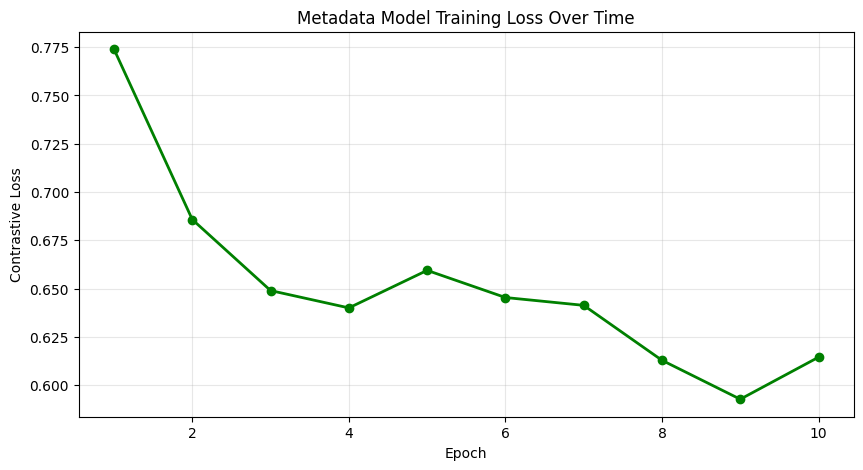


Final loss: 0.6145


In [63]:
# Train the metadata MLP model
import torch.optim as optim
from tqdm.auto import tqdm

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

# Initialize metadata model
metadata_model = MetadataMLP(embedding_dim=128, num_terrains=9).to(device)
criterion = ContrastiveLoss(margin=2.0)
optimizer = optim.Adam(metadata_model.parameters(), lr=0.001)

# Training function for metadata
def train_metadata_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for (pace1, terrain1, dist1), (pace2, terrain2, dist2), labels in tqdm(dataloader, desc="Training Metadata"):
        # Move to device
        pace1 = pace1.squeeze(1).to(device)
        terrain1 = terrain1.to(device)
        dist1 = dist1.squeeze(1).to(device)
        
        pace2 = pace2.squeeze(1).to(device)
        terrain2 = terrain2.to(device)
        dist2 = dist2.squeeze(1).to(device)
        
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        output1 = model(pace1, terrain1, dist1)
        output2 = model(pace2, terrain2, dist2)
        
        # Calculate loss
        loss = criterion(output1, output2, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Train metadata model
num_epochs = 10
print(f"\n🚀 Starting metadata model training for {num_epochs} epochs...")
print("=" * 60)

metadata_history = {'loss': []}

for epoch in range(num_epochs):
    avg_loss = train_metadata_epoch(metadata_model, metadata_dataloader, 
                                     criterion, optimizer, device)
    metadata_history['loss'].append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("\n✅ Metadata model training complete!")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), metadata_history['loss'], marker='o', linewidth=2, color='green')
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Metadata Model Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {metadata_history['loss'][-1]:.4f}")

In [64]:
# Hybrid Model: Combine CNN (shape) + MLP (metadata) embeddings
class HybridRouteModel(nn.Module):
    """
    Combines CNN embeddings (route shape) and MLP embeddings (metadata)
    """
    def __init__(self, cnn_model, mlp_model, fusion_dim=128):
        super(HybridRouteModel, self).__init__()
        
        self.cnn = cnn_model
        self.mlp = mlp_model
        
        # Fusion layer: combine both 128-dim embeddings
        # Input: 128 (CNN) + 128 (MLP) = 256
        self.fusion = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, fusion_dim)
        )
        
    def forward(self, img, pace, terrain, distance):
        """
        Args:
            img: (batch, 1, 64, 64) - route image
            pace: (batch, 1) - pace in min/km
            terrain: (batch, 9) - one-hot terrain
            distance: (batch, 1) - distance in km
        Returns:
            fused_embedding: (batch, 128)
        """
        # Get CNN embedding
        cnn_embed = self.cnn(img)
        
        # Get MLP embedding
        mlp_embed = self.mlp(pace, terrain, distance)
        
        # Concatenate
        combined = torch.cat([cnn_embed, mlp_embed], dim=1)
        
        # Fuse
        fused = self.fusion(combined)
        
        # L2 normalize
        fused = F.normalize(fused, p=2, dim=1)
        
        return fused, cnn_embed, mlp_embed

# Create hybrid model
hybrid_model = HybridRouteModel(model, metadata_model, fusion_dim=128).to(device)
print(f"✅ Hybrid model created!")
print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")

# Test with dummy data
dummy_img = torch.randn(4, 1, 64, 64).to(device)
dummy_pace = torch.randn(4, 1).to(device)
dummy_terrain = torch.zeros(4, 9).to(device)
dummy_terrain[:, 0] = 1
dummy_distance = torch.randn(4, 1).to(device)

fused, cnn_out, mlp_out = hybrid_model(dummy_img, dummy_pace, dummy_terrain, dummy_distance)
print(f"\nInput shapes:")
print(f"  Image: {dummy_img.shape}")
print(f"  Pace: {dummy_pace.shape}")
print(f"  Terrain: {dummy_terrain.shape}")
print(f"  Distance: {dummy_distance.shape}")
print(f"\nOutput shapes:")
print(f"  CNN embedding: {cnn_out.shape}")
print(f"  MLP embedding: {mlp_out.shape}")
print(f"  Fused embedding: {fused.shape}")

print("\n📊 Hybrid model architecture:")
print(hybrid_model)

✅ Hybrid model created!
Total parameters: 4,556,096

Input shapes:
  Image: torch.Size([4, 1, 64, 64])
  Pace: torch.Size([4, 1])
  Terrain: torch.Size([4, 9])
  Distance: torch.Size([4, 1])

Output shapes:
  CNN embedding: torch.Size([4, 128])
  MLP embedding: torch.Size([4, 128])
  Fused embedding: torch.Size([4, 128])

📊 Hybrid model architecture:
HybridRouteModel(
  (cnn): RouteCNN(
    (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): Batc

In [66]:
# Combined dataset for hybrid training (both image and metadata)
class HybridDataset(Dataset):
    """
    Dataset that provides both route images and metadata for hybrid training
    """
    def __init__(self, jsonl_path, num_routes=1000, augmenter=None):
        self.jsonl_path = jsonl_path
        self.num_routes = num_routes
        self.augmenter = augmenter or RouteImageAugmentation()
        
        # Terrain mapping
        self.terrain_to_idx = {
            'urban': 0, 'suburb': 1, 'park': 2, 'trail': 3,
            'forest': 4, 'coast': 5, 'hills': 6, 'mountain': 7, 'mixed': 8
        }
        
        print(f"Loading {num_routes} routes with images and metadata...")
        self.routes = []
        
        with open(jsonl_path, 'r') as f:
            for i, line in enumerate(f):
                if i >= num_routes:
                    break
                route = json.loads(line)
                
                # Need both geometry and metadata
                geometry = route.get('geometry', [])
                if (geometry and len(geometry) >= 2 and
                    'PaceMinPerKm' in route and 'Terrain' in route and
                    'Distance' in route and route['Distance'] > 0):
                    
                    img = route_to_image(geometry, img_size=64)
                    if img is not None:
                        terrain = route['Terrain']
                        if terrain in self.terrain_to_idx:
                            self.routes.append({
                                'img': img,
                                'pace': route['PaceMinPerKm'],
                                'terrain': terrain,
                                'distance': route['Distance'] / 1000.0
                            })
        
        print(f"✅ Loaded {len(self.routes)} valid routes with images + metadata")
    
    def terrain_to_onehot(self, terrain):
        onehot = torch.zeros(9)
        onehot[self.terrain_to_idx[terrain]] = 1.0
        return onehot
    
    def __len__(self):
        return len(self.routes) * 2
    
    def __getitem__(self, idx):
        if idx % 2 == 0:
            # Positive pair: same route OR similar characteristics
            route_idx = (idx // 2) % len(self.routes)
            route1 = self.routes[route_idx]
            
            # 70% same route (different augmentations)
            # 30% similar route (same terrain or similar pace)
            if np.random.random() < 0.7:
                # Same route, different augmentations
                route2 = route1
            else:
                # Similar route
                similar_candidates = []
                for i, r in enumerate(self.routes):
                    if i != route_idx:
                        if (r['terrain'] == route1['terrain'] or 
                            abs(r['pace'] - route1['pace']) < 1.5):
                            similar_candidates.append(i)
                
                if similar_candidates:
                    route2_idx = np.random.choice(similar_candidates)
                    route2 = self.routes[route2_idx]
                else:
                    route2 = route1
            
            label = torch.tensor(0.0)
            
        else:
            # Negative pair: different routes with different characteristics
            route_idx1 = (idx // 2) % len(self.routes)
            route1 = self.routes[route_idx1]
            
            # Find dissimilar
            dissimilar_candidates = []
            for i, r in enumerate(self.routes):
                if i != route_idx1:
                    if (r['terrain'] != route1['terrain'] and 
                        abs(r['pace'] - route1['pace']) > 2.0):
                        dissimilar_candidates.append(i)
            
            if dissimilar_candidates:
                route2_idx = np.random.choice(dissimilar_candidates)
                route2 = self.routes[route2_idx]
            else:
                route2_idx = (route_idx1 + len(self.routes) // 2) % len(self.routes)
                route2 = self.routes[route2_idx]
            
            label = torch.tensor(1.0)
        
        # Route 1
        img1 = self.augmenter(route1['img'])
        pace1 = torch.tensor([[route1['pace']]], dtype=torch.float32)
        terrain1 = self.terrain_to_onehot(route1['terrain'])
        dist1 = torch.tensor([[route1['distance']]], dtype=torch.float32)
        
        # Route 2
        img2 = self.augmenter(route2['img'])
        pace2 = torch.tensor([[route2['pace']]], dtype=torch.float32)
        terrain2 = self.terrain_to_onehot(route2['terrain'])
        dist2 = torch.tensor([[route2['distance']]], dtype=torch.float32)
        
        return (img1, pace1, terrain1, dist1), (img2, pace2, terrain2, dist2), label

# Create hybrid dataset
hybrid_dataset = HybridDataset("WorldTrace_20k.jsonl", num_routes=1000)
hybrid_dataloader = DataLoader(hybrid_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\n📦 Hybrid dataset ready!")
print(f"   Total samples per epoch: {len(hybrid_dataset)}")
print(f"   Batches per epoch: {len(hybrid_dataloader)}")

# Test
(img1, pace1, terrain1, dist1), (img2, pace2, terrain2, dist2), labels = next(iter(hybrid_dataloader))
print(f"\n🔍 Sample batch:")
print(f"   Image 1: {img1.shape}, Pace 1: {pace1.shape}")
print(f"   Terrain 1: {terrain1.shape}, Distance 1: {dist1.shape}")
print(f"   Positive: {(labels == 0).sum().item()}, Negative: {(labels == 1).sum().item()}")

Loading 1000 routes with images and metadata...
✅ Loaded 1000 valid routes with images + metadata

📦 Hybrid dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63

🔍 Sample batch:
   Image 1: torch.Size([32, 1, 64, 64]), Pace 1: torch.Size([32, 1, 1])
   Terrain 1: torch.Size([32, 9]), Distance 1: torch.Size([32, 1, 1])
   Positive: 20, Negative: 12
✅ Loaded 1000 valid routes with images + metadata

📦 Hybrid dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63

🔍 Sample batch:
   Image 1: torch.Size([32, 1, 64, 64]), Pace 1: torch.Size([32, 1, 1])
   Terrain 1: torch.Size([32, 9]), Distance 1: torch.Size([32, 1, 1])
   Positive: 20, Negative: 12


🔄 Creating fresh hybrid model for end-to-end training...
Total parameters: 4,556,096

🚀 Starting hybrid model training for 10 epochs...


Training Hybrid:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.6499


Training Hybrid:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 0.4862


...

Epoch 8/10 - Loss: 0.4265


Training Hybrid:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.4299


Training Hybrid:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.4136

✅ Hybrid model training complete!


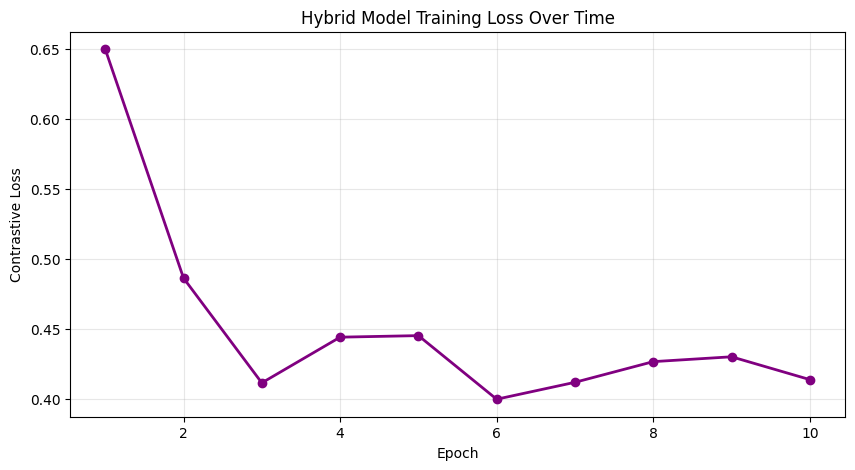


Final loss: 0.4136

💡 The hybrid model now combines both:
   - Route shape features (from CNN)
   - Metadata features (pace, terrain, distance from MLP)
   - Fused into a single 128-dim embedding!


In [67]:
# Train the hybrid model end-to-end
import torch.optim as optim
from tqdm.auto import tqdm

# Re-initialize fresh hybrid model for training
print("🔄 Creating fresh hybrid model for end-to-end training...")
hybrid_model = HybridRouteModel(
    cnn_model=RouteCNN(embedding_dim=128),
    mlp_model=MetadataMLP(embedding_dim=128, num_terrains=9),
    fusion_dim=128
).to(device)

criterion = ContrastiveLoss(margin=2.0)
optimizer = optim.Adam(hybrid_model.parameters(), lr=0.001)

print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")

# Training function for hybrid model
def train_hybrid_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for (img1, pace1, terrain1, dist1), (img2, pace2, terrain2, dist2), labels in tqdm(dataloader, desc="Training Hybrid"):
        # Move to device
        img1 = img1.to(device)
        pace1 = pace1.squeeze(1).to(device)
        terrain1 = terrain1.to(device)
        dist1 = dist1.squeeze(1).to(device)
        
        img2 = img2.to(device)
        pace2 = pace2.squeeze(1).to(device)
        terrain2 = terrain2.to(device)
        dist2 = dist2.squeeze(1).to(device)
        
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        fused1, cnn1, mlp1 = model(img1, pace1, terrain1, dist1)
        fused2, cnn2, mlp2 = model(img2, pace2, terrain2, dist2)
        
        # Calculate loss on fused embeddings
        loss = criterion(fused1, fused2, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Train hybrid model
num_epochs = 10
print(f"\n🚀 Starting hybrid model training for {num_epochs} epochs...")
print("=" * 60)

hybrid_history = {'loss': []}

for epoch in range(num_epochs):
    avg_loss = train_hybrid_epoch(hybrid_model, hybrid_dataloader, 
                                   criterion, optimizer, device)
    hybrid_history['loss'].append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("\n✅ Hybrid model training complete!")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), hybrid_history['loss'], marker='o', linewidth=2, color='purple')
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Hybrid Model Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {hybrid_history['loss'][-1]:.4f}")
print("\n💡 The hybrid model now combines both:")
print("   - Route shape features (from CNN)")
print("   - Metadata features (pace, terrain, distance from MLP)")
print("   - Fused into a single 128-dim embedding!")

🔍 Testing hybrid model - finding similar routes using shape + metadata...
Computing embeddings for all routes...
✅ Generated 1000 hybrid embeddings

📍 Query Route #0
   Pace: 6.52 min/km
   Terrain: Park
   Distance: 0.46 km
✅ Generated 1000 hybrid embeddings

📍 Query Route #0
   Pace: 6.52 min/km
   Terrain: Park
   Distance: 0.46 km


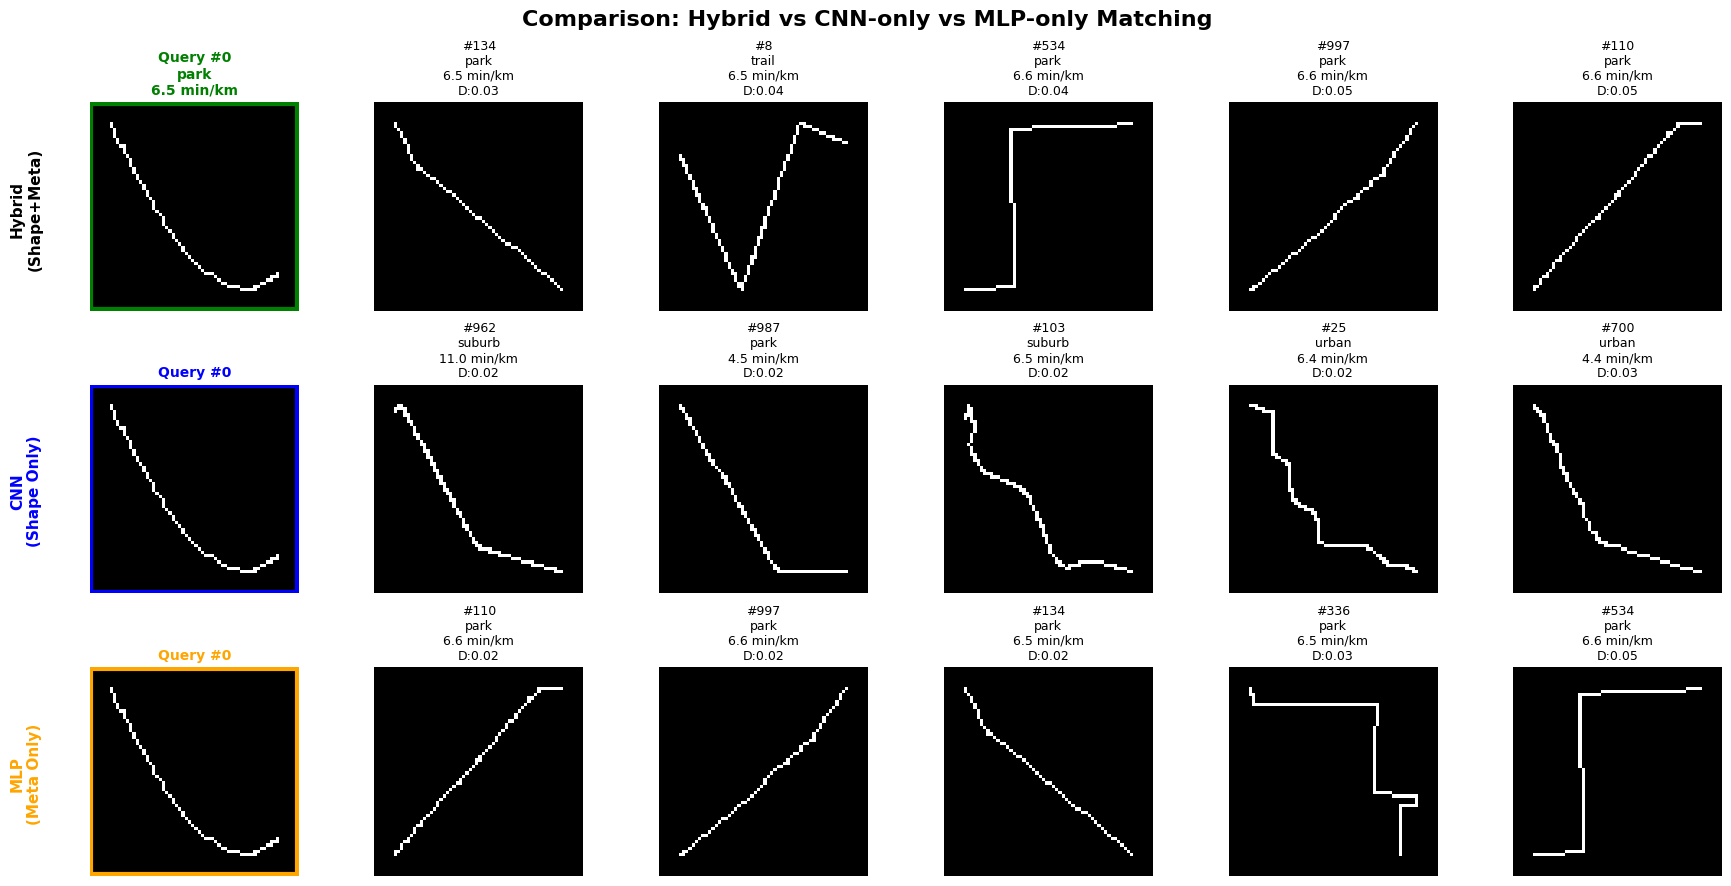


📊 Top 5 Matches Comparison:

HYBRID (Shape + Metadata):
  1. Route #134 - park       6.5 min/km - Dist: 0.033
  2. Route #8 - trail      6.5 min/km - Dist: 0.040
  3. Route #534 - park       6.6 min/km - Dist: 0.042
  4. Route #997 - park       6.6 min/km - Dist: 0.048
  5. Route #110 - park       6.6 min/km - Dist: 0.051

CNN ONLY (Shape):
  1. Route #962 - suburb    11.0 min/km - Dist: 0.019
  2. Route #987 - park       4.5 min/km - Dist: 0.020
  3. Route #103 - suburb     6.5 min/km - Dist: 0.023
  4. Route #25 - urban      6.4 min/km - Dist: 0.025
  5. Route #700 - urban      4.4 min/km - Dist: 0.026

MLP ONLY (Metadata):
  1. Route #110 - park       6.6 min/km - Dist: 0.016
  2. Route #997 - park       6.6 min/km - Dist: 0.022
  3. Route #134 - park       6.5 min/km - Dist: 0.023
  4. Route #336 - park       6.5 min/km - Dist: 0.025
  5. Route #534 - park       6.6 min/km - Dist: 0.046

💡 Notice:
   - Hybrid: Balanced matches considering both shape and characteristics
   - CNN: F

In [68]:
# Test hybrid model: Find similar routes using combined embeddings
print("🔍 Testing hybrid model - finding similar routes using shape + metadata...")

# Get embeddings for all routes
hybrid_model.eval()
all_embeddings = []
all_cnn_embeddings = []
all_mlp_embeddings = []

print("Computing embeddings for all routes...")
with torch.no_grad():
    for i in range(len(hybrid_dataset.routes)):
        route = hybrid_dataset.routes[i]
        
        # Prepare inputs
        img = torch.from_numpy(route['img']).float().unsqueeze(0).unsqueeze(0) / 255.0
        pace = torch.tensor([[route['pace']]], dtype=torch.float32)
        terrain = hybrid_dataset.terrain_to_onehot(route['terrain']).unsqueeze(0)
        dist = torch.tensor([[route['distance']]], dtype=torch.float32)
        
        # Move to device
        img = img.to(device)
        pace = pace.to(device)
        terrain = terrain.to(device)
        dist = dist.to(device)
        
        # Get embeddings
        fused, cnn, mlp = hybrid_model(img, pace, terrain, dist)
        
        all_embeddings.append(fused.cpu().numpy())
        all_cnn_embeddings.append(cnn.cpu().numpy())
        all_mlp_embeddings.append(mlp.cpu().numpy())

all_embeddings = np.vstack(all_embeddings)
all_cnn_embeddings = np.vstack(all_cnn_embeddings)
all_mlp_embeddings = np.vstack(all_mlp_embeddings)

print(f"✅ Generated {len(all_embeddings)} hybrid embeddings")

# Pick first route as query
query_idx = 0
query_route = hybrid_dataset.routes[query_idx]

# Compute distances in different embedding spaces
fused_distances = np.linalg.norm(all_embeddings - all_embeddings[query_idx], axis=1)
cnn_distances = np.linalg.norm(all_cnn_embeddings - all_cnn_embeddings[query_idx], axis=1)
mlp_distances = np.linalg.norm(all_mlp_embeddings - all_mlp_embeddings[query_idx], axis=1)

# Get top matches for each embedding type
fused_matches = np.argsort(fused_distances)[1:6]
cnn_matches = np.argsort(cnn_distances)[1:6]
mlp_matches = np.argsort(mlp_distances)[1:6]

print(f"\n📍 Query Route #{query_idx}")
print(f"   Pace: {query_route['pace']:.2f} min/km")
print(f"   Terrain: {query_route['terrain'].title()}")
print(f"   Distance: {query_route['distance']:.2f} km")

# Visualize comparison
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

# Row 0: Query + Hybrid matches
axes[0, 0].imshow(query_route['img'], cmap='gray')
axes[0, 0].set_title(f"Query #{query_idx}\n{query_route['terrain']}\n{query_route['pace']:.1f} min/km", 
                     fontsize=10, fontweight='bold', color='green')
axes[0, 0].axis('off')
axes[0, 0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))

for i, match_idx in enumerate(fused_matches, start=1):
    match_route = hybrid_dataset.routes[match_idx]
    axes[0, i].imshow(match_route['img'], cmap='gray')
    axes[0, i].set_title(f"#{match_idx}\n{match_route['terrain']}\n{match_route['pace']:.1f} min/km\nD:{fused_distances[match_idx]:.2f}", 
                        fontsize=9)
    axes[0, i].axis('off')

axes[0, 0].text(-20, 32, 'Hybrid\n(Shape+Meta)', fontsize=11, fontweight='bold', 
                rotation=90, va='center', ha='center')

# Row 1: Query + CNN matches (shape only)
axes[1, 0].imshow(query_route['img'], cmap='gray')
axes[1, 0].set_title(f"Query #{query_idx}", fontsize=10, fontweight='bold', color='blue')
axes[1, 0].axis('off')
axes[1, 0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='blue', linewidth=3))

for i, match_idx in enumerate(cnn_matches, start=1):
    match_route = hybrid_dataset.routes[match_idx]
    axes[1, i].imshow(match_route['img'], cmap='gray')
    axes[1, i].set_title(f"#{match_idx}\n{match_route['terrain']}\n{match_route['pace']:.1f} min/km\nD:{cnn_distances[match_idx]:.2f}", 
                        fontsize=9)
    axes[1, i].axis('off')

axes[1, 0].text(-20, 32, 'CNN\n(Shape Only)', fontsize=11, fontweight='bold', 
                rotation=90, va='center', ha='center', color='blue')

# Row 2: Query + MLP matches (metadata only)
axes[2, 0].imshow(query_route['img'], cmap='gray')
axes[2, 0].set_title(f"Query #{query_idx}", fontsize=10, fontweight='bold', color='orange')
axes[2, 0].axis('off')
axes[2, 0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='orange', linewidth=3))

for i, match_idx in enumerate(mlp_matches, start=1):
    match_route = hybrid_dataset.routes[match_idx]
    axes[2, i].imshow(match_route['img'], cmap='gray')
    axes[2, i].set_title(f"#{match_idx}\n{match_route['terrain']}\n{match_route['pace']:.1f} min/km\nD:{mlp_distances[match_idx]:.2f}", 
                        fontsize=9)
    axes[2, i].axis('off')

axes[2, 0].text(-20, 32, 'MLP\n(Meta Only)', fontsize=11, fontweight='bold', 
                rotation=90, va='center', ha='center', color='orange')

plt.suptitle('Comparison: Hybrid vs CNN-only vs MLP-only Matching', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 Matches Comparison:")
print("=" * 80)
print("\nHYBRID (Shape + Metadata):")
for rank, idx in enumerate(fused_matches, start=1):
    r = hybrid_dataset.routes[idx]
    print(f"  {rank}. Route #{idx} - {r['terrain']:8s} {r['pace']:5.1f} min/km - Dist: {fused_distances[idx]:.3f}")

print("\nCNN ONLY (Shape):")
for rank, idx in enumerate(cnn_matches, start=1):
    r = hybrid_dataset.routes[idx]
    print(f"  {rank}. Route #{idx} - {r['terrain']:8s} {r['pace']:5.1f} min/km - Dist: {cnn_distances[idx]:.3f}")

print("\nMLP ONLY (Metadata):")
for rank, idx in enumerate(mlp_matches, start=1):
    r = hybrid_dataset.routes[idx]
    print(f"  {rank}. Route #{idx} - {r['terrain']:8s} {r['pace']:5.1f} min/km - Dist: {mlp_distances[idx]:.3f}")

print("\n💡 Notice:")
print("   - Hybrid: Balanced matches considering both shape and characteristics")
print("   - CNN: Focuses on visual shape similarity")
print("   - MLP: Focuses on pace/terrain similarity (shapes may differ)")